# Generative Adversarial Networks (GANs)

This is my single notebook for the whole assignment. It runs top to bottom, and it's meant to be run on a GPU runtime with internet access on (some datasets download the first time).

| Part | What it covers |
|------|------|
| Part 1 | GANs from scratch on synthetic 2D data (sine wave, mixture of Gaussians, and an architecture comparison) |
| Part 2.1 | Medical imaging DCGAN on OCTMNIST, plus a conditional-GAN extension |
| Part 2.2 | Cybersecurity feature-vector GAN on CICIDS 2017 (Wednesday), compared with PCA/t-SNE |
| Part 2.3 | Creative DCGAN on QuickDraw 'birthday cake', plus an extra-categories extension |


## Environment setup (run this first)

This installs the handful of packages that aren't always already on the runtime. I put torch in first so that nothing installed afterwards quietly pulls in a different build over the top of it. Running the cell again doesn't hurt anything because pip just skips whatever is already present. One thing I hit occasionally: if TensorFlow doesn't pick up the GPU straight after installing, restarting the kernel once and re-running fixes it.

In [1]:
def install_packages(*packages):
    """Quietly pip-install into the running kernel."""
    import sys
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *packages], check=False)


# torch first, so the installs below can't quietly swap it for another build
install_packages("torch", "torchvision")
install_packages("scipy", "scikit-learn", "pandas", "matplotlib", "pillow", "tqdm", "requests", "medmnist")
install_packages("tensorflow[and-cuda]")   # GPU build; drop [and-cuda] for CPU-only
print("Environment setup complete.")

Environment setup complete.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.10.0+cu128 requires nvidia-nccl-cu12==2.27.5; platform_system == "Linux", but you have nvidia-nccl-cu12 2.30.7 which is incompatible.


> **Which framework is used where:** Parts 1, 2.1 and 2.2 are written in PyTorch, and Part 2.3 (QuickDraw) is in TensorFlow/Keras. Part 2 lets you use either one, so I've used both to show I can work in each.

## Environment, seeding and device selection

`configure_global_reproducibility()` fixes the seed (42) for Python's `random`, NumPy and PyTorch (both CPU and CUDA) and puts cuDNN into deterministic mode. I call it again right before every training run in the notebook - Task 1, Task 2, Task 3, the baseline vs enhanced comparison, and each of the Part 2 datasets - so that each run starts from the same reset state instead of inheriting whatever the previous run left the random number generators in. Without this the later runs would drift depending on what ran before them.

Device selection falls back to CPU when there's no GPU, but on this runtime it finds one immediately:

```
PyTorch version      : 2.10.0+cu128
Selected compute unit: cuda
  GPU 0: NVIDIA A10G
Results directory    : results
```

The `results/` folder is created here too - that's where all the figures and metrics later on get written.

In [2]:
# Only MedMNIST usually needs installing; torch, torchvision, numpy, scipy,
# matplotlib and scikit-learn already ship with the runtime.
#
# Install MedMNIST with --no-deps so pip doesn't reinstall torch/torchvision.
# Swapping the preinstalled GPU-matched torch is what triggers the
# 'CUDA error: no kernel image is available' crash. MedMNIST's runtime imports
# (numpy, Pillow, torch, scikit-learn, requests) are already here.
#
# Reuses install_packages(...) defined in the environment-setup cell above.
install_packages("--no-deps", "medmnist")


In [3]:
import os
import math
import random
from dataclasses import dataclass
from typing import Callable

import numpy as np
import scipy.linalg
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
import torchvision.utils as torchvision_utils
import matplotlib.pyplot as plt

# Seed every random source so the report figures come out the same each run.
GLOBAL_RANDOM_SEED = 42


def configure_global_reproducibility(random_seed: int = GLOBAL_RANDOM_SEED) -> None:
    """Seed Python, NumPy and PyTorch (CPU and CUDA) for deterministic runs.

    cuDNN is also pinned to deterministic mode, so re-running with the same seed gives
    the same weights and the same FID instead of the usual run-to-run wobble.
    """
    random.seed(random_seed)
    np.random.seed(random_seed)
    torch.manual_seed(random_seed)
    torch.cuda.manual_seed_all(random_seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


configure_global_reproducibility()

# use the GPU if there is one, else CPU
COMPUTE_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# torch.cuda.is_available() only checks the driver, so it can return True even when
# the torch build has no kernels for this GPU. That only bites once a kernel runs, so
# try a tiny op now and drop to CPU with a clear message if it fails.
if COMPUTE_DEVICE.type == "cuda":
    try:
        _cuda_probe_result = torch.randn(8, 8, device=COMPUTE_DEVICE) @ torch.randn(8, 8, device=COMPUTE_DEVICE)
        torch.cuda.synchronize()
        del _cuda_probe_result
    except RuntimeError as cuda_probe_error:
        print("WARNING: CUDA is reported available but a test kernel failed:")
        print(f"  {cuda_probe_error}")
        print("This usually means the installed torch build does not match the GPU")
        print("(often because a pip install replaced the preinstalled torch).")
        print("Falling back to CPU. To use the GPU: enable the GPU accelerator, keep the")
        print("MedMNIST install as --no-deps so torch is not reinstalled, then")
        print("factory-reset the session and re-run.")
        COMPUTE_DEVICE = torch.device("cpu")

# results folder (zipped at the end)
RESULTS_DIRECTORY = "results"
os.makedirs(RESULTS_DIRECTORY, exist_ok=True)

print(f"PyTorch version      : {torch.__version__}")
print(f"Selected compute unit: {COMPUTE_DEVICE}")
if COMPUTE_DEVICE.type == "cuda":
    for gpu_index in range(torch.cuda.device_count()):
        print(f"  GPU {gpu_index}: {torch.cuda.get_device_name(gpu_index)}")
print(f"Results directory    : {RESULTS_DIRECTORY}")

PyTorch version      : 2.10.0+cu128
Selected compute unit: cuda
  GPU 0: NVIDIA A10G
Results directory    : results


In [4]:
# One switch for run length:
#   True  -> a few epochs, just to check it all runs end-to-end
#   False -> the full run that produces the report figures
QUICK_SMOKE_TEST = False

# settings tuned for a single 24 GB GPU (NVIDIA A10G)
AVAILABLE_GPU_COUNT = torch.cuda.device_count()

# For 32x32 DCGANs a single GPU is faster than splitting each batch over two: the
# models are tiny, so DataParallel's scatter/gather costs more than it saves (multi-GPU
# only helps big models/images). So keep one GPU and spend the memory on a bigger batch
# and more data instead. Set True only to force batch-sharding across GPUs.
USE_DATA_PARALLEL = False

# Training-length configuration, kept in one place for transparency.
IMAGE_GAN_EPOCHS = 3 if QUICK_SMOKE_TEST else 40
IMAGE_GAN_BATCH_SIZE = 128 if QUICK_SMOKE_TEST else 256        # plenty of headroom at 32x32
MAX_IMAGES_PER_DATASET = 4000 if QUICK_SMOKE_TEST else 40000   # more data, better samples
FID_SAMPLE_COUNT = 500 if QUICK_SMOKE_TEST else 5000           # above the 2048 Inception dims, so the covariance is full-rank

print(f"QUICK_SMOKE_TEST = {QUICK_SMOKE_TEST} | epochs = {IMAGE_GAN_EPOCHS} | batch = {IMAGE_GAN_BATCH_SIZE}")
print(f"GPUs available   = {AVAILABLE_GPU_COUNT} | USE_DATA_PARALLEL = {USE_DATA_PARALLEL}")

QUICK_SMOKE_TEST = False | epochs = 40 | batch = 256
GPUs available   = 1 | USE_DATA_PARALLEL = False


## Shared helper functions

A few small helpers that get reused throughout the notebook: the DCGAN weight initialisation, the loss-curve and sample-grid plotting functions, and a self-contained FID that I built on top of a torchvision InceptionV3 feature extractor. I kept FID self-contained on purpose so I'm not relying on a separate FID package that could fail to download or break on a version bump.

In [5]:
def initialise_dcgan_weights(neural_module: nn.Module) -> None:
    """DCGAN-paper weight init, applied in place via model.apply(...).

    Conv/ConvTranspose weights ~ N(0, 0.02); BatchNorm weights ~ N(1, 0.02), zero bias.
    """
    module_class_name = neural_module.__class__.__name__
    if "Conv" in module_class_name:
        nn.init.normal_(neural_module.weight.data, 0.0, 0.02)
    elif "BatchNorm" in module_class_name:
        nn.init.normal_(neural_module.weight.data, 1.0, 0.02)
        nn.init.constant_(neural_module.bias.data, 0.0)


def maybe_data_parallel(model: nn.Module) -> nn.Module:
    """Wrap the model in DataParallel only if USE_DATA_PARALLEL and >1 GPU.

    Otherwise it returns the model untouched, so the default single-GPU path is
    unchanged.
    """
    if USE_DATA_PARALLEL and AVAILABLE_GPU_COUNT > 1:
        return nn.DataParallel(model)
    return model


def plot_adversarial_loss_curves(
    discriminator_losses: list[float],
    generator_losses: list[float],
    plot_title: str,
    output_path: str | None = None,
    smoothing_window: int = 50,
) -> None:
    """Plot the discriminator and generator losses (moving-average smoothed)."""
    def moving_average(values: list[float]) -> np.ndarray:
        if len(values) < smoothing_window:
            return np.asarray(values, dtype=float)
        kernel = np.ones(smoothing_window) / smoothing_window
        return np.convolve(values, kernel, mode="valid")

    plt.figure(figsize=(8, 4))
    plt.plot(moving_average(discriminator_losses), label="Discriminator", color="#1f77b4")
    plt.plot(moving_average(generator_losses), label="Generator", color="#d62728")
    plt.title(plot_title)
    plt.xlabel("Training step (smoothed)")
    plt.ylabel("BCE loss")
    plt.legend()
    plt.grid(alpha=0.2)
    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()


@torch.no_grad()
def plot_image_sample_grid(
    image_batch: Tensor,
    plot_title: str,
    output_path: str | None = None,
    grid_row_count: int = 8,
) -> None:
    """Show a grid of images given in the [-1, 1] tanh range."""
    images_in_unit_range = (image_batch.detach().cpu().clamp(-1, 1) + 1.0) / 2.0
    image_grid = torchvision_utils.make_grid(images_in_unit_range, nrow=grid_row_count, padding=2)
    plt.figure(figsize=(8, 8))
    plt.imshow(image_grid.permute(1, 2, 0).squeeze().numpy(), cmap="gray")
    plt.title(plot_title)
    plt.axis("off")
    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()


@torch.no_grad()
def plot_real_versus_fake_grids(real_images_tanh_range, fake_images_tanh_range, plot_title,
                                output_path=None, number_shown=32):
    """Side-by-side real vs generated image grids (inputs in the [-1, 1] tanh range)."""
    figure, axes = plt.subplots(1, 2, figsize=(12, 6))
    for axis, image_batch, subtitle in (
        (axes[0], real_images_tanh_range, "Real"),
        (axes[1], fake_images_tanh_range, "Generated (fake)"),
    ):
        unit_range = (image_batch[:number_shown].detach().cpu().clamp(-1, 1) + 1.0) / 2.0
        image_grid = torchvision_utils.make_grid(unit_range, nrow=8, padding=2)
        axis.imshow(image_grid.permute(1, 2, 0).squeeze().numpy(), cmap="gray")
        axis.set_title(subtitle); axis.axis("off")
    figure.suptitle(plot_title)
    if output_path:
        figure.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()


@torch.no_grad()
def render_epoch_progression(progression_snapshots, plot_title, output_path=None):
    """Show generated-sample grids from several epochs, side by side.

    Takes a list of (epoch, image_batch) pairs in the [-1, 1] range. This is the
    brief's 'visual outputs across epochs'.
    """
    if not progression_snapshots:
        return
    snapshot_count = len(progression_snapshots)
    figure, axes = plt.subplots(1, snapshot_count, figsize=(3.2 * snapshot_count, 3.6))
    if snapshot_count == 1:
        axes = [axes]
    for axis, (epoch_index, image_batch) in zip(axes, progression_snapshots):
        unit_range = (image_batch.detach().cpu().clamp(-1, 1) + 1.0) / 2.0
        image_grid = torchvision_utils.make_grid(unit_range, nrow=4, padding=2)
        axis.imshow(image_grid.permute(1, 2, 0).squeeze().numpy(), cmap="gray")
        axis.set_title(f"epoch {epoch_index}"); axis.axis("off")
    figure.suptitle(plot_title)
    if output_path:
        figure.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()

In [6]:
# Frechet Inception Distance (FID), self-contained so nothing extra has to download.
from torchvision.models import inception_v3, Inception_V3_Weights


class InceptionFeatureExtractor(nn.Module):
    """torchvision InceptionV3 exposing its 2048-d pooled feature vector.

    FID compares the mean and covariance of these features for the real vs generated
    sets. Images are resized to 299x299 and normalised with the ImageNet stats.
    """

    IMAGENET_MEAN = (0.485, 0.456, 0.406)
    IMAGENET_STD = (0.229, 0.224, 0.225)

    def __init__(self, device: torch.device) -> None:
        super().__init__()
        self.inception_network = inception_v3(weights=Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)
        self.inception_network.fc = nn.Identity()  # expose the 2048-d pooled features
        self.inception_network.eval().to(device)
        self.inception_network = maybe_data_parallel(self.inception_network)  # spread the 299x299 passes over GPUs if enabled
        self.device = device
        normalisation_mean = torch.tensor(self.IMAGENET_MEAN, device=device).view(1, 3, 1, 1)
        normalisation_std = torch.tensor(self.IMAGENET_STD, device=device).view(1, 3, 1, 1)
        self.register_buffer("normalisation_mean", normalisation_mean)
        self.register_buffer("normalisation_std", normalisation_std)

    @torch.no_grad()
    def extract_features(self, images_unit_range: Tensor, batch_size: int = 50) -> np.ndarray:
        """Return (N, 2048) features for images given in the [0, 1] range."""
        if images_unit_range.shape[1] == 1:  # grayscale -> 3 channels
            images_unit_range = images_unit_range.repeat(1, 3, 1, 1)

        collected_features: list[np.ndarray] = []
        for start_index in range(0, images_unit_range.shape[0], batch_size):
            image_chunk = images_unit_range[start_index:start_index + batch_size].to(self.device)
            image_chunk = F.interpolate(image_chunk, size=(299, 299), mode="bilinear", align_corners=False)
            image_chunk = (image_chunk - self.normalisation_mean) / self.normalisation_std
            feature_chunk = self.inception_network(image_chunk)
            collected_features.append(feature_chunk.cpu().numpy())
        return np.concatenate(collected_features, axis=0)


def _matrix_square_root(square_matrix: np.ndarray) -> np.ndarray:
    """Real matrix square root via scipy, coping with both return conventions.

    Older SciPy returns a (matrix, error) tuple; newer SciPy (>= 1.18) returns just the
    matrix. Handle both so this keeps working across versions.
    """
    sqrt_result = scipy.linalg.sqrtm(square_matrix)
    if isinstance(sqrt_result, tuple):  # older SciPy returned (sqrtm, error_estimate)
        sqrt_result = sqrt_result[0]
    if np.iscomplexobj(sqrt_result):
        sqrt_result = sqrt_result.real
    return sqrt_result


def compute_frechet_inception_distance(
    real_images_unit_range: Tensor,
    fake_images_unit_range: Tensor,
    feature_extractor: InceptionFeatureExtractor,
    numerical_stability_epsilon: float = 1e-6,
) -> float:
    """FID between two image sets given in [0, 1] (lower is better).

    FID is the Frechet distance between two Gaussians fitted to each set's InceptionV3
    features. If the covariance-product square root comes out non-finite (rank-deficient
    covariance when #samples < feature dim), a small diagonal offset is added, the same
    trick pytorch-fid uses.
    """
    real_features = feature_extractor.extract_features(real_images_unit_range)
    fake_features = feature_extractor.extract_features(fake_images_unit_range)

    real_mean, fake_mean = real_features.mean(axis=0), fake_features.mean(axis=0)
    real_covariance = np.cov(real_features, rowvar=False)
    fake_covariance = np.cov(fake_features, rowvar=False)

    mean_difference = real_mean - fake_mean
    covariance_product_sqrt = _matrix_square_root(real_covariance.dot(fake_covariance))

    if not np.isfinite(covariance_product_sqrt).all():
        diagonal_offset = np.eye(real_covariance.shape[0]) * numerical_stability_epsilon
        covariance_product_sqrt = _matrix_square_root(
            (real_covariance + diagonal_offset).dot(fake_covariance + diagonal_offset)
        )

    frechet_distance = (
        mean_difference.dot(mean_difference)
        + np.trace(real_covariance + fake_covariance - 2.0 * covariance_product_sqrt)
    )
    return float(frechet_distance)

# Part 1 - Building a GAN from scratch

Here I work with synthetic 2D data and write the generator and discriminator as small MLPs. Both are produced by one configurable builder, which means Task 3 (the architecture change) can reuse exactly the same training code without me having to duplicate anything.

## The target ('real') distributions

Two sampler functions return the "real" 2D points that the discriminator gets trained against:

- `sample_sine_wave_distribution` draws `x` uniformly on `[-pi, pi]` and sets `y = sin(x)`. This is the tutorial's target and what I use for Task 1.
- `sample_mixture_of_gaussians_distribution` is my Task 2 distribution: eight small isotropic Gaussians spaced evenly around a ring (radius 2.0, per-mode std 0.05). I picked a ring of well-separated blobs deliberately, because it's a well-known way to test for mode collapse - if the generator collapses it will visibly only cover a few of the eight blobs instead of all of them.

Both functions return an `(N, 2)` tensor, so the same generator, discriminator and training loop below can be pointed at either one.

In [7]:
def sample_sine_wave_distribution(batch_size: int, x_lower: float = -math.pi, x_upper: float = math.pi) -> Tensor:
    """Sample real 2D points lying on y = sin(x); returns shape (batch_size, 2)."""
    horizontal_positions = torch.rand(batch_size, 1) * (x_upper - x_lower) + x_lower
    vertical_positions = torch.sin(horizontal_positions)
    return torch.cat([horizontal_positions, vertical_positions], dim=1)


def sample_mixture_of_gaussians_distribution(
    batch_size: int,
    number_of_modes: int = 8,
    ring_radius: float = 2.0,
    per_mode_standard_deviation: float = 0.05,
) -> Tensor:
    """Sample from a ring of 2D isotropic Gaussians, shape (batch_size, 2).

    The ring makes mode collapse easy to see: a collapsed generator only covers some
    of the blobs.
    """
    mode_angles = torch.arange(number_of_modes, dtype=torch.float32) * (2.0 * math.pi / number_of_modes)
    mode_centres = torch.stack([ring_radius * torch.cos(mode_angles), ring_radius * torch.sin(mode_angles)], dim=1)
    assigned_mode_indices = torch.randint(low=0, high=number_of_modes, size=(batch_size,))
    selected_centres = mode_centres[assigned_mode_indices]
    gaussian_noise = torch.randn(batch_size, 2) * per_mode_standard_deviation
    return selected_centres + gaussian_noise

## A configurable generator and discriminator

`ArchitectureConfiguration` holds the depth and activation function, so the same two classes can produce both the baseline network and the modified one I use in Task 3. That's the whole reason I made it configurable - I didn't want two near-identical copies of the model code.

In [8]:
@dataclass
class ArchitectureConfiguration:
    """The settings that define one MLP generator/discriminator."""

    latent_dimension: int = 16
    hidden_width: int = 128
    hidden_depth: int = 2
    activation_name: str = "relu"           # "relu", "leaky_relu" or "selu"
    leaky_relu_negative_slope: float = 0.2

    def build_activation_module(self) -> nn.Module:
        if self.activation_name == "relu":
            return nn.ReLU(inplace=True)
        if self.activation_name == "leaky_relu":
            return nn.LeakyReLU(self.leaky_relu_negative_slope, inplace=True)
        if self.activation_name == "selu":
            return nn.SELU(inplace=True)
        raise ValueError(f"Unsupported activation: {self.activation_name!r}")


def _build_mlp_trunk(input_dimension: int, configuration: ArchitectureConfiguration) -> tuple[list[nn.Module], int]:
    """Build the shared hidden-layer stack; return (layers, final_hidden_width)."""
    layers: list[nn.Module] = []
    current_dimension = input_dimension
    for _ in range(configuration.hidden_depth):
        layers.append(nn.Linear(current_dimension, configuration.hidden_width))
        layers.append(configuration.build_activation_module())
        current_dimension = configuration.hidden_width
    return layers, current_dimension


class TwoDimensionalGenerator(nn.Module):
    """MLP mapping latent noise z ~ N(0, I) to a synthetic 2D point."""

    def __init__(self, configuration: ArchitectureConfiguration) -> None:
        super().__init__()
        trunk_layers, final_hidden_width = _build_mlp_trunk(configuration.latent_dimension, configuration)
        trunk_layers.append(nn.Linear(final_hidden_width, 2))  # 2D output, no activation
        self.network = nn.Sequential(*trunk_layers)

    def forward(self, latent_noise: Tensor) -> Tensor:
        return self.network(latent_noise)


class TwoDimensionalDiscriminator(nn.Module):
    """MLP mapping a 2D point to a single real/fake logit (no final sigmoid)."""

    def __init__(self, configuration: ArchitectureConfiguration) -> None:
        super().__init__()
        trunk_layers, final_hidden_width = _build_mlp_trunk(2, configuration)
        trunk_layers.append(nn.Linear(final_hidden_width, 1))
        self.network = nn.Sequential(*trunk_layers)

    def forward(self, sample_points: Tensor) -> Tensor:
        return self.network(sample_points)

## The adversarial training loop

I'm using the non-saturating GAN objective through `BCEWithLogitsLoss`. The discriminator learns to tell real points from generated ones, and the generator is trained to make the discriminator score its samples as real.

In [9]:
def train_two_dimensional_gan(
    real_data_sampler: Callable[[int], Tensor],
    architecture: ArchitectureConfiguration,
    number_of_training_steps: int = 8000,
    batch_size: int = 256,
    learning_rate: float = 2e-4,
    adam_betas: tuple[float, float] = (0.5, 0.999),
    device: torch.device = COMPUTE_DEVICE,
    logging_interval: int = 2000,
) -> tuple[TwoDimensionalGenerator, list[float], list[float]]:
    """Train a 2D GAN; return (generator, discriminator_losses, generator_losses)."""
    generator = TwoDimensionalGenerator(architecture).to(device)
    discriminator = TwoDimensionalDiscriminator(architecture).to(device)

    generator_optimizer = torch.optim.Adam(generator.parameters(), lr=learning_rate, betas=adam_betas)
    discriminator_optimizer = torch.optim.Adam(discriminator.parameters(), lr=learning_rate, betas=adam_betas)
    binary_cross_entropy = nn.BCEWithLogitsLoss()

    discriminator_loss_history: list[float] = []
    generator_loss_history: list[float] = []
    real_label_value, fake_label_value = 1.0, 0.0

    for training_step in range(1, number_of_training_steps + 1):
        # discriminator update
        real_points = real_data_sampler(batch_size).to(device)
        latent_noise = torch.randn(batch_size, architecture.latent_dimension, device=device)
        generated_points = generator(latent_noise).detach()

        real_logits = discriminator(real_points)
        fake_logits = discriminator(generated_points)
        discriminator_loss = (
            binary_cross_entropy(real_logits, torch.full_like(real_logits, real_label_value))
            + binary_cross_entropy(fake_logits, torch.full_like(fake_logits, fake_label_value))
        )
        discriminator_optimizer.zero_grad(set_to_none=True)
        discriminator_loss.backward()
        discriminator_optimizer.step()

        # generator update
        latent_noise = torch.randn(batch_size, architecture.latent_dimension, device=device)
        generator_logits = discriminator(generator(latent_noise))
        generator_loss = binary_cross_entropy(generator_logits, torch.full_like(generator_logits, real_label_value))
        generator_optimizer.zero_grad(set_to_none=True)
        generator_loss.backward()
        generator_optimizer.step()

        discriminator_loss_history.append(float(discriminator_loss.item()))
        generator_loss_history.append(float(generator_loss.item()))
        if training_step % logging_interval == 0 or training_step == 1:
            print(f"step {training_step:>6}/{number_of_training_steps} | "
                  f"D={discriminator_loss.item():.4f} | G={generator_loss.item():.4f}")

    return generator, discriminator_loss_history, generator_loss_history


@torch.no_grad()
def draw_generated_2d_samples(
    generator: TwoDimensionalGenerator, architecture: ArchitectureConfiguration,
    number_of_samples: int, device: torch.device = COMPUTE_DEVICE,
) -> np.ndarray:
    """Sample points from a trained 2D generator as a NumPy array."""
    generator.eval()
    latent_noise = torch.randn(number_of_samples, architecture.latent_dimension, device=device)
    generated_points = generator(latent_noise).cpu().numpy()
    generator.train()
    return generated_points


def plot_real_versus_generated_2d(
    real_points: np.ndarray, generated_points: np.ndarray, plot_title: str, output_path: str | None = None,
) -> None:
    """Overlay real and generated 2D point clouds."""
    plt.figure(figsize=(6, 6))
    plt.scatter(real_points[:, 0], real_points[:, 1], s=6, alpha=0.4, label="Real", color="#1f77b4")
    plt.scatter(generated_points[:, 0], generated_points[:, 1], s=6, alpha=0.4, label="Generated", color="#d62728")
    plt.title(plot_title)
    plt.xlabel("x"); plt.ylabel("y"); plt.legend(loc="upper right"); plt.grid(alpha=0.2)
    plt.gca().set_aspect("equal", adjustable="datalim")
    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()

## Task 1: reproduce the sine-wave GAN

This is the baseline MLP (16-d latent vector, width 128, depth 2, ReLU) trained for 6000 steps directly against `sample_sine_wave_distribution`. It's the run that's closest to the tutorial, and I'm mainly using it as a sanity check - if the shared training loop, loss function and plotting utilities all behave here, I can trust them when I reuse them on the harder Task 2 and Task 3 targets.

step      1/6000 | D=1.4351 | G=0.6650
step   2000/6000 | D=1.3620 | G=0.7089
step   4000/6000 | D=1.3787 | G=0.6814
step   6000/6000 | D=1.3778 | G=0.6964


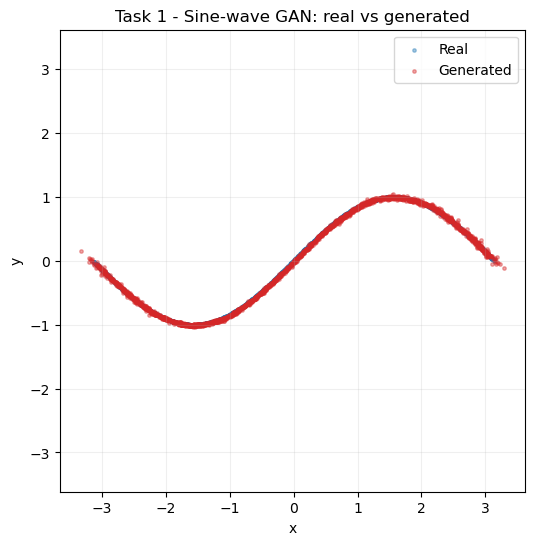

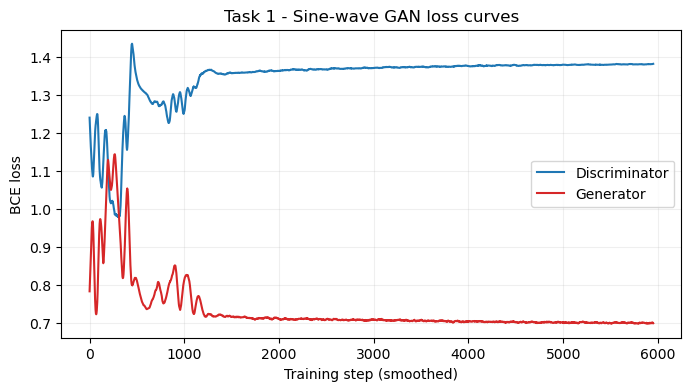

In [10]:
configure_global_reproducibility()
sine_wave_architecture = ArchitectureConfiguration(latent_dimension=16, hidden_width=128, hidden_depth=2, activation_name="relu")

sine_generator, sine_d_losses, sine_g_losses = train_two_dimensional_gan(
    real_data_sampler=sample_sine_wave_distribution, architecture=sine_wave_architecture, number_of_training_steps=6000,
)

sine_real_points = sample_sine_wave_distribution(2000).numpy()
sine_generated_points = draw_generated_2d_samples(sine_generator, sine_wave_architecture, 2000)
plot_real_versus_generated_2d(sine_real_points, sine_generated_points,
    "Task 1 - Sine-wave GAN: real vs generated", os.path.join(RESULTS_DIRECTORY, "part1_task1_sine.png"))
plot_adversarial_loss_curves(sine_d_losses, sine_g_losses,
    "Task 1 - Sine-wave GAN loss curves", os.path.join(RESULTS_DIRECTORY, "part1_task1_sine_loss.png"))

## Task 2: mixture of Gaussians (watching for mode collapse)

Same baseline architecture and the same training loop as Task 1, but now aimed at the 8-mode Gaussian ring and run for 8000 steps (the multi-modal target is harder than a single sine curve, so it needs a bit longer to settle). I plot both the loss curves and the real-vs-generated scatter, because mode collapse would show up in two places: the generator loss diverging or oscillating, and the generated points bunching onto fewer than eight of the ring's modes.

step      1/8000 | D=1.4611 | G=0.6652
step   2000/8000 | D=0.9764 | G=1.0190
step   4000/8000 | D=0.8879 | G=1.2157
step   6000/8000 | D=0.7095 | G=1.5478
step   8000/8000 | D=0.9547 | G=1.0874


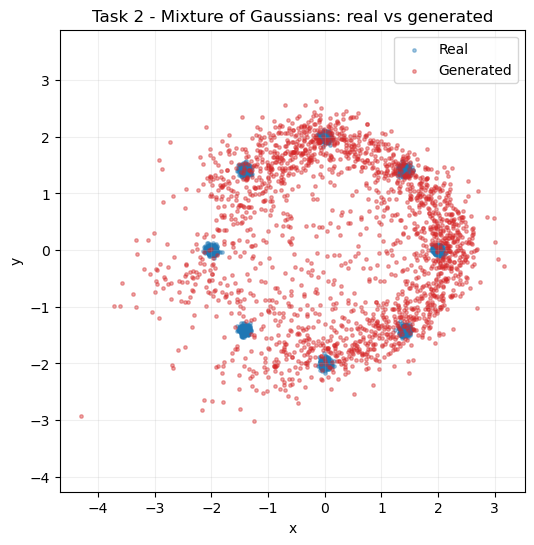

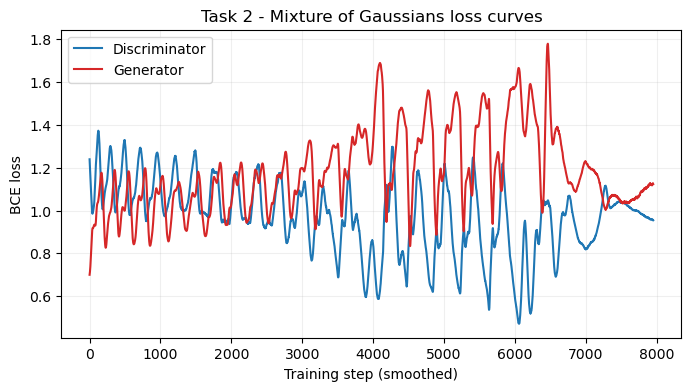

In [11]:
configure_global_reproducibility()
mixture_architecture = ArchitectureConfiguration(latent_dimension=16, hidden_width=128, hidden_depth=2, activation_name="relu")

mixture_generator, mixture_d_losses, mixture_g_losses = train_two_dimensional_gan(
    real_data_sampler=sample_mixture_of_gaussians_distribution, architecture=mixture_architecture, number_of_training_steps=8000,
)

mixture_real_points = sample_mixture_of_gaussians_distribution(2000).numpy()
mixture_generated_points = draw_generated_2d_samples(mixture_generator, mixture_architecture, 2000)
plot_real_versus_generated_2d(mixture_real_points, mixture_generated_points,
    "Task 2 - Mixture of Gaussians: real vs generated", os.path.join(RESULTS_DIRECTORY, "part1_task2_mixture.png"))
plot_adversarial_loss_curves(mixture_d_losses, mixture_g_losses,
    "Task 2 - Mixture of Gaussians loss curves", os.path.join(RESULTS_DIRECTORY, "part1_task2_mixture_loss.png"))

## Task 3: change the architecture and compare

For the architecture modification I kept everything else identical and only changed the depth, width and activation:

| Architecture | Depth | Width | Activation |
|--------------|-------|-------|------------|
| Baseline | 2 | 128 | ReLU |
| Enhanced | 4 | 256 | SELU |

step      1/8000 | D=1.4611 | G=0.6652
step   2000/8000 | D=0.9764 | G=1.0190
step   4000/8000 | D=0.8879 | G=1.2157
step   6000/8000 | D=0.7095 | G=1.5478
step   8000/8000 | D=0.9547 | G=1.0874
step      1/8000 | D=1.3827 | G=0.8670
step   2000/8000 | D=1.3477 | G=0.9660
step   4000/8000 | D=1.3888 | G=0.8144
step   6000/8000 | D=1.1920 | G=1.0786
step   8000/8000 | D=1.4444 | G=0.8657


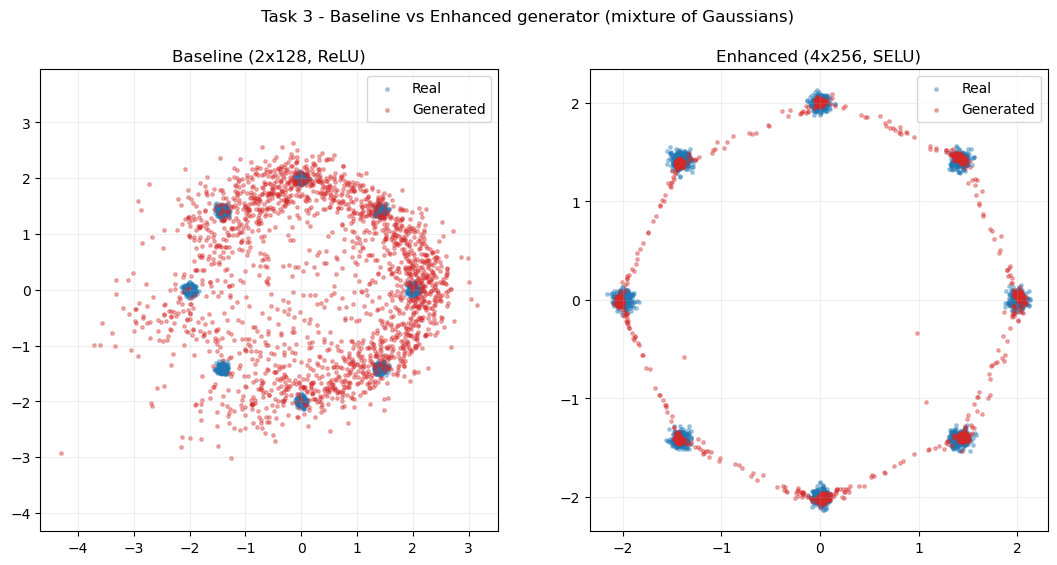

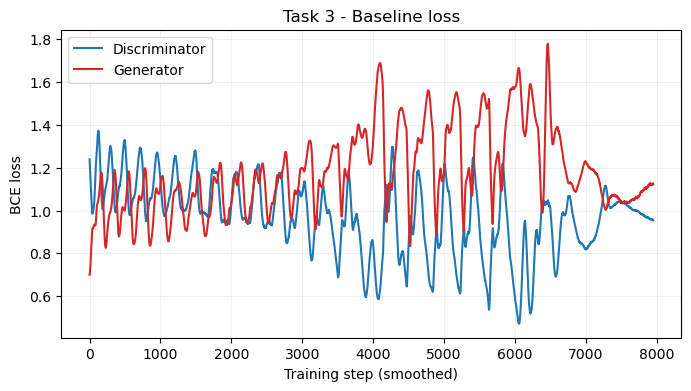

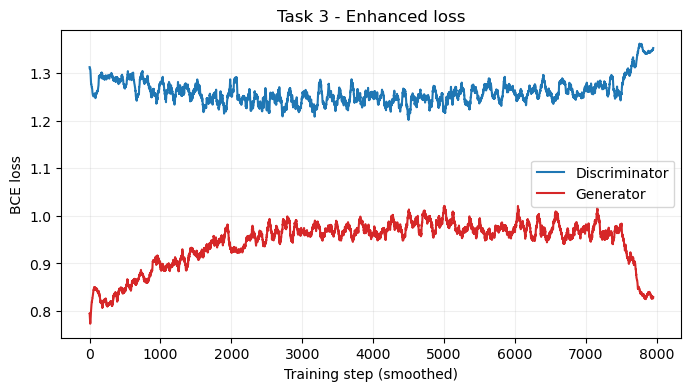

In [12]:
configure_global_reproducibility()
baseline_architecture = ArchitectureConfiguration(hidden_width=128, hidden_depth=2, activation_name="relu")
enhanced_architecture = ArchitectureConfiguration(hidden_width=256, hidden_depth=4, activation_name="selu")

baseline_generator, baseline_d_losses, baseline_g_losses = train_two_dimensional_gan(
    sample_mixture_of_gaussians_distribution, baseline_architecture, number_of_training_steps=8000)

configure_global_reproducibility()
enhanced_generator, enhanced_d_losses, enhanced_g_losses = train_two_dimensional_gan(
    sample_mixture_of_gaussians_distribution, enhanced_architecture, number_of_training_steps=8000)

comparison_real_points = sample_mixture_of_gaussians_distribution(2000).numpy()
baseline_generated_points = draw_generated_2d_samples(baseline_generator, baseline_architecture, 2000)
enhanced_generated_points = draw_generated_2d_samples(enhanced_generator, enhanced_architecture, 2000)

figure, axes = plt.subplots(1, 2, figsize=(13, 6))
for axis, generated_points, subtitle in (
    (axes[0], baseline_generated_points, "Baseline (2x128, ReLU)"),
    (axes[1], enhanced_generated_points, "Enhanced (4x256, SELU)"),
):
    axis.scatter(comparison_real_points[:, 0], comparison_real_points[:, 1], s=6, alpha=0.35, label="Real", color="#1f77b4")
    axis.scatter(generated_points[:, 0], generated_points[:, 1], s=6, alpha=0.35, label="Generated", color="#d62728")
    axis.set_title(subtitle); axis.legend(loc="upper right"); axis.grid(alpha=0.2)
    axis.set_aspect("equal", adjustable="datalim")
figure.suptitle("Task 3 - Baseline vs Enhanced generator (mixture of Gaussians)")
figure.savefig(os.path.join(RESULTS_DIRECTORY, "part1_task3_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

plot_adversarial_loss_curves(baseline_d_losses, baseline_g_losses, "Task 3 - Baseline loss", os.path.join(RESULTS_DIRECTORY, "part1_task3_baseline_loss.png"))
plot_adversarial_loss_curves(enhanced_d_losses, enhanced_g_losses, "Task 3 - Enhanced loss", os.path.join(RESULTS_DIRECTORY, "part1_task3_enhanced_loss.png"))

## What the three runs show

A few things stand out to me here.

On the sine wave the two losses sit close to their equilibrium values for basically the whole run (the discriminator hovers around 1.38 and the generator around 0.70), and the generated points land on the `sin(x)` curve with only a bit of wobble near the turning points. So the basic setup clearly works.

The mixture of Gaussians is the more interesting target. The generator does reach all eight modes rather than parking itself on one or two, so there's no hard mode collapse - but the samples are noticeably loose. The red cloud fills the ring and spills into some of the gaps between blobs instead of sitting tightly on the eight centres. That's the classic "it covers the modes, just not sharply" behaviour you get from a small vanilla GAN.

Task 3 is where the architecture change makes the clearest difference. Holding everything else fixed and going from the 2x128 ReLU network to the 4x256 SELU one tightens the samples a lot: the enhanced generator concentrates on the eight modes and traces a clean ring, while the baseline stays scattered. So in this case the extra depth and width, plus the smoother SELU activation, mostly buy me sharper and better-localised samples rather than fixing a collapse that never really happened in the first place.

# Part 2 - Real-world GAN applications (shared DCGAN core)

Part 2.1 (OCTMNIST) uses the PyTorch DCGAN defined in this section. Part 2.3 (QuickDraw) is built separately in TensorFlow/Keras further down. I work the images at 32x32 - a clean power of two that divides nicely across the four conv / transpose-conv stages - and scale them to [-1, 1] so they match the generator's final Tanh output.

In [13]:
def _build_dcgan_generator_stack(input_channels: int, feature_maps: int, image_channels: int) -> nn.Sequential:
    """ConvTranspose stack: (input_channels,1,1) -> (image_channels,32,32) in [-1,1]."""
    return nn.Sequential(
        nn.ConvTranspose2d(input_channels, feature_maps * 4, 4, 1, 0, bias=False),
        nn.BatchNorm2d(feature_maps * 4), nn.ReLU(True),                                  # -> 4x4
        nn.ConvTranspose2d(feature_maps * 4, feature_maps * 2, 4, 2, 1, bias=False),
        nn.BatchNorm2d(feature_maps * 2), nn.ReLU(True),                                  # -> 8x8
        nn.ConvTranspose2d(feature_maps * 2, feature_maps, 4, 2, 1, bias=False),
        nn.BatchNorm2d(feature_maps), nn.ReLU(True),                                      # -> 16x16
        nn.ConvTranspose2d(feature_maps, image_channels, 4, 2, 1, bias=False),
        nn.Tanh(),                                                                        # -> 32x32
    )


def _build_dcgan_discriminator_stack(input_channels: int, feature_maps: int) -> nn.Sequential:
    """Conv stack: (input_channels,32,32) -> single logit at (1,1,1)."""
    return nn.Sequential(
        nn.Conv2d(input_channels, feature_maps, 4, 2, 1, bias=False),
        nn.LeakyReLU(0.2, inplace=True), nn.Dropout(0.3),                                                  # -> 16x16
        nn.Conv2d(feature_maps, feature_maps * 2, 4, 2, 1, bias=False),
        nn.BatchNorm2d(feature_maps * 2), nn.LeakyReLU(0.2, inplace=True), nn.Dropout(0.3),                # -> 8x8
        nn.Conv2d(feature_maps * 2, feature_maps * 4, 4, 2, 1, bias=False),
        nn.BatchNorm2d(feature_maps * 4), nn.LeakyReLU(0.2, inplace=True), nn.Dropout(0.3),                # -> 4x4
        nn.Conv2d(feature_maps * 4, 1, 4, 1, 0, bias=False),                              # -> 1x1 logit
    )


DCGAN_LATENT_DIMENSION = 100


class DcganGenerator(nn.Module):
    """Unconditional DCGAN generator for 32x32 single-channel images."""

    def __init__(self, latent_dimension: int = DCGAN_LATENT_DIMENSION, feature_maps: int = 64, image_channels: int = 1) -> None:
        super().__init__()
        self.network = _build_dcgan_generator_stack(latent_dimension, feature_maps, image_channels)

    def forward(self, latent_noise: Tensor) -> Tensor:
        return self.network(latent_noise)


class DcganDiscriminator(nn.Module):
    """Unconditional DCGAN discriminator returning a raw real/fake logit."""

    def __init__(self, feature_maps: int = 64, image_channels: int = 1) -> None:
        super().__init__()
        self.network = _build_dcgan_discriminator_stack(image_channels, feature_maps)

    def forward(self, images: Tensor) -> Tensor:
        return self.network(images).view(-1, 1)

In [14]:
def preprocess_grayscale_images_to_tensor(images_uint8: np.ndarray, target_size: int = 32) -> Tensor:
    """Convert (N, H, W) uint8 images to (N, 1, target_size, target_size) in [-1, 1]."""
    image_tensor = torch.from_numpy(images_uint8).float().unsqueeze(1)  # (N,1,H,W)
    image_tensor = image_tensor / 127.5 - 1.0                            # -> [-1, 1]
    if image_tensor.shape[-1] != target_size:
        image_tensor = F.interpolate(image_tensor, size=(target_size, target_size), mode="bilinear", align_corners=False)
    return image_tensor


def build_image_dataloader(image_tensor: Tensor, batch_size: int, labels: Tensor | None = None) -> DataLoader:
    """Wrap an image tensor (and optional labels) in a shuffled DataLoader."""
    dataset = TensorDataset(image_tensor, labels) if labels is not None else TensorDataset(image_tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True, num_workers=2)


def build_class_balanced_dataloader(image_tensor: Tensor, class_labels: Tensor, batch_size: int) -> DataLoader:
    """DataLoader that draws every class with equal probability.

    OCTMNIST is very imbalanced (normal is about 6x drusen). Weighting each sample by
    1 / (its class frequency) via WeightedRandomSampler makes the classes appear
    equally often, so the cGAN actually learns the rare ones.
    """
    class_labels_long = class_labels.long()
    per_class_counts = torch.bincount(class_labels_long).float().clamp(min=1.0)
    per_sample_weights = (1.0 / per_class_counts)[class_labels_long]
    balanced_sampler = WeightedRandomSampler(
        weights=per_sample_weights, num_samples=len(class_labels_long), replacement=True,
    )
    dataset = TensorDataset(image_tensor, class_labels_long)
    return DataLoader(dataset, batch_size=batch_size, sampler=balanced_sampler, drop_last=True, num_workers=2)


def train_dcgan(
    generator: DcganGenerator,
    discriminator: DcganDiscriminator,
    dataloader: DataLoader,
    number_of_epochs: int,
    latent_dimension: int = DCGAN_LATENT_DIMENSION,
    learning_rate: float = 2e-4,
    adam_betas: tuple[float, float] = (0.5, 0.999),
    device: torch.device = COMPUTE_DEVICE,
    figure_prefix: str = "dcgan",
    number_of_progress_snapshots: int = 5,
    real_label_smoothing: float = 0.9,
) -> tuple[list[float], list[float]]:
    """Train an unconditional DCGAN; return (discriminator_losses, generator_losses).

    A fixed noise batch is sampled at several evenly spaced epochs so the report can
    show generated 'visual outputs across epochs', plus a final larger sample grid.
    """
    generator.apply(initialise_dcgan_weights)
    discriminator.apply(initialise_dcgan_weights)

    generator_optimizer = torch.optim.Adam(generator.parameters(), lr=learning_rate, betas=adam_betas)
    discriminator_optimizer = torch.optim.Adam(discriminator.parameters(), lr=learning_rate, betas=adam_betas)
    binary_cross_entropy = nn.BCEWithLogitsLoss()

    fixed_monitoring_noise = torch.randn(64, latent_dimension, 1, 1, device=device)
    fixed_progression_noise = torch.randn(16, latent_dimension, 1, 1, device=device)
    snapshot_epochs = sorted(set(int(round(v)) for v in np.linspace(1, number_of_epochs, number_of_progress_snapshots)))
    progression_snapshots: list = []
    discriminator_loss_history: list[float] = []
    generator_loss_history: list[float] = []

    for epoch_index in range(1, number_of_epochs + 1):
        for real_image_batch, in dataloader:
            real_image_batch = real_image_batch.to(device)
            current_batch_size = real_image_batch.size(0)

            # discriminator update
            latent_noise = torch.randn(current_batch_size, latent_dimension, 1, 1, device=device)
            generated_images = generator(latent_noise).detach()
            real_logits = discriminator(real_image_batch)
            fake_logits = discriminator(generated_images)
            # One-sided label smoothing (real target = 0.9) keeps the discriminator
            # from becoming over-confident, which is the usual cause of D loss -> 0.
            discriminator_loss = (
                binary_cross_entropy(real_logits, torch.full_like(real_logits, real_label_smoothing))
                + binary_cross_entropy(fake_logits, torch.zeros_like(fake_logits))
            )
            discriminator_optimizer.zero_grad(set_to_none=True)
            discriminator_loss.backward()
            discriminator_optimizer.step()

            # generator update
            latent_noise = torch.randn(current_batch_size, latent_dimension, 1, 1, device=device)
            generator_logits = discriminator(generator(latent_noise))
            generator_loss = binary_cross_entropy(generator_logits, torch.ones_like(generator_logits))
            generator_optimizer.zero_grad(set_to_none=True)
            generator_loss.backward()
            generator_optimizer.step()

            discriminator_loss_history.append(float(discriminator_loss.item()))
            generator_loss_history.append(float(generator_loss.item()))

        print(f"epoch {epoch_index:>3}/{number_of_epochs} | D={discriminator_loss.item():.4f} | G={generator_loss.item():.4f}")
        if epoch_index in snapshot_epochs:
            with torch.no_grad():
                progression_snapshots.append((epoch_index, generator(fixed_progression_noise).cpu()))

    # Brief requirement: show generated 'visual outputs across epochs'.
    render_epoch_progression(
        progression_snapshots, f"{figure_prefix}: generated samples across epochs",
        os.path.join(RESULTS_DIRECTORY, f"{figure_prefix}_progression.png"),
    )
    # Plus a final, larger sample grid for the report.
    with torch.no_grad():
        final_monitoring_images = generator(fixed_monitoring_noise)
    plot_image_sample_grid(
        final_monitoring_images, f"{figure_prefix}: generated samples (final epoch)",
        os.path.join(RESULTS_DIRECTORY, f"{figure_prefix}_final_samples.png"),
    )
    return discriminator_loss_history, generator_loss_history


@torch.no_grad()
def generate_dcgan_image_batch(
    generator: DcganGenerator, number_of_images: int,
    latent_dimension: int = DCGAN_LATENT_DIMENSION, device: torch.device = COMPUTE_DEVICE,
) -> Tensor:
    """Generate a batch of images in the [-1, 1] range from a trained DCGAN."""
    generator.eval()
    latent_noise = torch.randn(number_of_images, latent_dimension, 1, 1, device=device)
    generated_images = generator(latent_noise).cpu()
    generator.train()
    return generated_images

# Part 2.1 - Medical imaging: OCTMNIST DCGAN

OCTMNIST (part of MedMNIST) is 28x28 grayscale OCT retinal scans across four diagnostic classes. In this part I explore the data, train a DCGAN to generate retinal scans, and then score the result with FID.

## Load and explore OCTMNIST

I load OCTMNIST through the `medmnist` package, which downloads it automatically the first time it's used. There are four diagnostic classes, and even the training split on its own is fairly large:

```
OCTMNIST classes: {'0': 'choroidal neovascularization', '1': 'diabetic macular edema', '2': 'drusen', '3': 'normal'}
OCTMNIST train images: (97477, 28, 28)
```

The class-distribution bar chart below shows the classes are clearly not balanced. That imbalance matters later: it's exactly what the class-balanced sampler in the conditional-GAN extension has to correct for, otherwise the minority classes barely get learned.

OCTMNIST classes: {'0': 'choroidal neovascularization', '1': 'diabetic macular edema', '2': 'drusen', '3': 'normal'}
OCTMNIST train images: (97477, 28, 28)


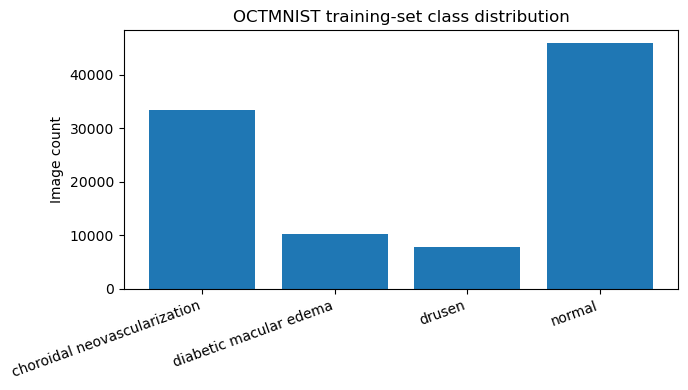

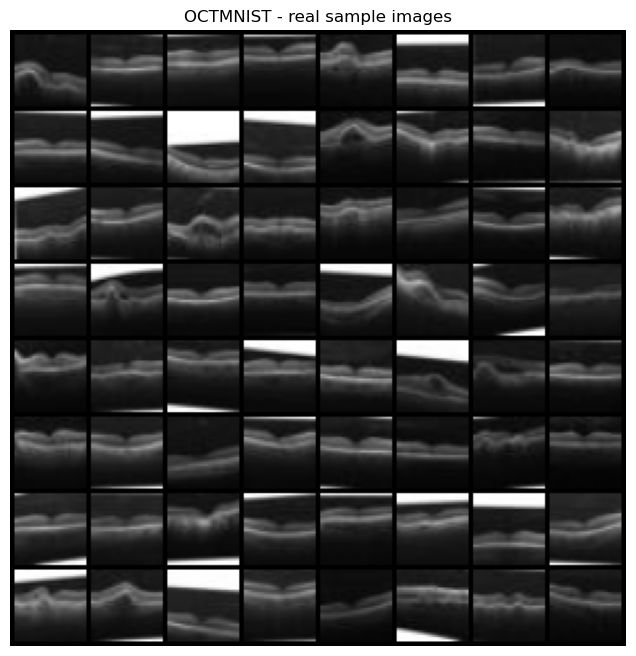

In [15]:
from medmnist import OCTMNIST, INFO

octmnist_metadata = INFO["octmnist"]
octmnist_class_labels = octmnist_metadata["label"]
print("OCTMNIST classes:", octmnist_class_labels)

octmnist_train_dataset = OCTMNIST(split="train", download=True)
octmnist_images_uint8 = octmnist_train_dataset.imgs           # (N, 28, 28) uint8
octmnist_labels = octmnist_train_dataset.labels.flatten()      # (N,) int
print("OCTMNIST train images:", octmnist_images_uint8.shape)

# class distribution
unique_classes, class_counts = np.unique(octmnist_labels, return_counts=True)
plt.figure(figsize=(7, 4))
plt.bar([octmnist_class_labels[str(int(c))] for c in unique_classes], class_counts, color="#1f77b4")
plt.title("OCTMNIST training-set class distribution")
plt.ylabel("Image count"); plt.xticks(rotation=20, ha="right"); plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIRECTORY, "octmnist_class_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

# a few real images
real_sample_tensor = preprocess_grayscale_images_to_tensor(octmnist_images_uint8[:64])
plot_image_sample_grid(real_sample_tensor, "OCTMNIST - real sample images",
    os.path.join(RESULTS_DIRECTORY, "octmnist_real_samples.png"))

## Train the OCTMNIST DCGAN

I take a random subset of `MAX_IMAGES_PER_DATASET` images (40,000 at full run length) and preprocess them from `(28, 28)` uint8 into `(1, 32, 32)` tensors scaled to `[-1, 1]` to match the generator's Tanh. Then I train a standard DCGAN pair (strided and transposed convolutions, BatchNorm, LeakyReLU in the discriminator and ReLU in the generator, with the DCGAN-paper weight init) for `IMAGE_GAN_EPOCHS` epochs (40 at full length) using the non-saturating adversarial loss.

You can see the printed per-epoch `D`/`G` losses move out of an early unbalanced phase (`D=0.39, G=5.35` at epoch 1, with the discriminator way ahead) into a much closer back-and-forth by the middle of training (roughly `D≈0.9-1.1`, `G≈1.3-2.3`). That's the shape I'd expect from a DCGAN that's actually learning rather than collapsing.

epoch   1/40 | D=0.3881 | G=5.3499
epoch   2/40 | D=0.4748 | G=4.0665
epoch   3/40 | D=1.0345 | G=1.8615
epoch   4/40 | D=0.8579 | G=2.3272
epoch   5/40 | D=1.1146 | G=1.3200
epoch   6/40 | D=0.9194 | G=1.6497
epoch   7/40 | D=0.9381 | G=1.2526
epoch   8/40 | D=1.0629 | G=2.0599
epoch   9/40 | D=1.0327 | G=1.1196
epoch  10/40 | D=0.9093 | G=1.3186
epoch  11/40 | D=0.9616 | G=2.6463
epoch  12/40 | D=0.8119 | G=1.6477
epoch  13/40 | D=0.8482 | G=2.8606
epoch  14/40 | D=0.6366 | G=2.1822
epoch  15/40 | D=0.5389 | G=2.8079
epoch  16/40 | D=0.8401 | G=3.0057
epoch  17/40 | D=0.8918 | G=1.6187
epoch  18/40 | D=0.6550 | G=3.6697
epoch  19/40 | D=3.1605 | G=1.0131
epoch  20/40 | D=0.6687 | G=3.2064
epoch  21/40 | D=0.5871 | G=2.6438
epoch  22/40 | D=0.4790 | G=3.0416
epoch  23/40 | D=0.5742 | G=3.7071
epoch  24/40 | D=0.5488 | G=3.6502
epoch  25/40 | D=0.4755 | G=2.7875
epoch  26/40 | D=0.5234 | G=3.1555
epoch  27/40 | D=0.4872 | G=2.9533
epoch  28/40 | D=0.5281 | G=2.6035
epoch  29/40 | D=0.5

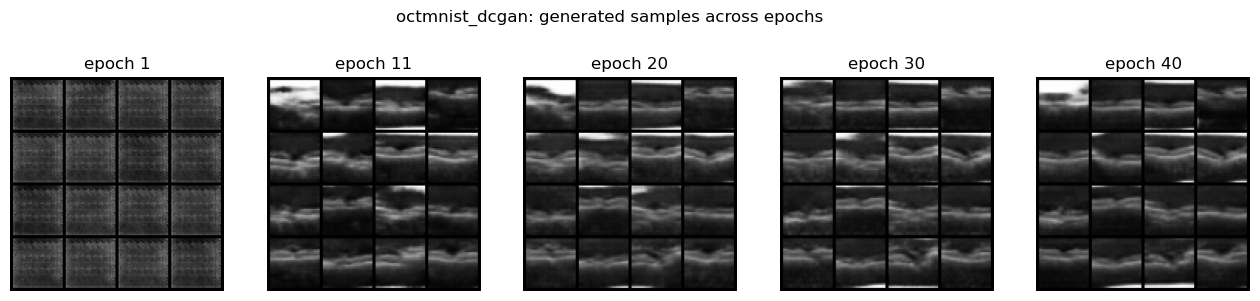

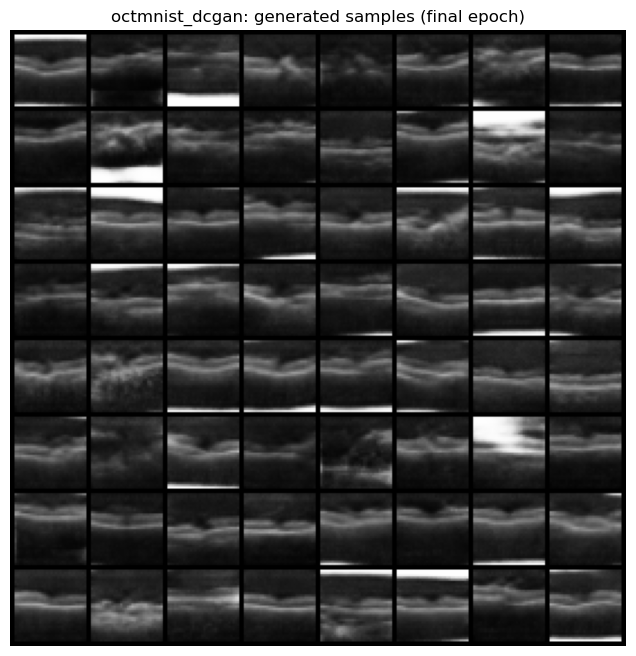

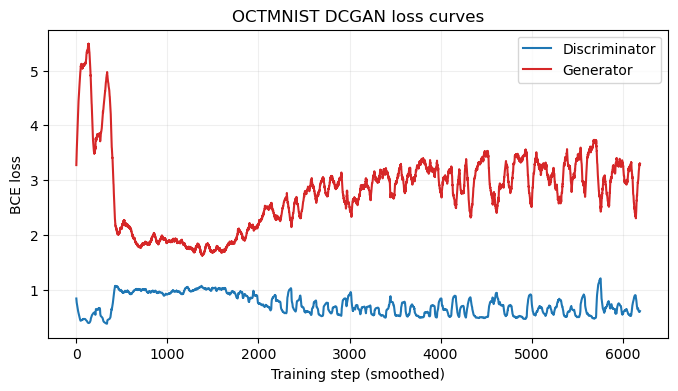

In [16]:
configure_global_reproducibility()

# subsample for a reasonable training time, then preprocess to (N,1,32,32) in [-1,1]
octmnist_subset_indices = np.random.permutation(len(octmnist_images_uint8))[:MAX_IMAGES_PER_DATASET]
octmnist_image_tensor = preprocess_grayscale_images_to_tensor(octmnist_images_uint8[octmnist_subset_indices])
octmnist_dataloader = build_image_dataloader(octmnist_image_tensor, IMAGE_GAN_BATCH_SIZE)

octmnist_generator = maybe_data_parallel(DcganGenerator().to(COMPUTE_DEVICE))
octmnist_discriminator = maybe_data_parallel(DcganDiscriminator().to(COMPUTE_DEVICE))

octmnist_d_losses, octmnist_g_losses = train_dcgan(
    octmnist_generator, octmnist_discriminator, octmnist_dataloader,
    number_of_epochs=IMAGE_GAN_EPOCHS, figure_prefix="octmnist_dcgan",
)
plot_adversarial_loss_curves(octmnist_d_losses, octmnist_g_losses,
    "OCTMNIST DCGAN loss curves", os.path.join(RESULTS_DIRECTORY, "octmnist_loss_curves.png"))

## Real vs fake, and the FID score

I generate fake images from the trained generator, show them as a sample grid, and put them next to real OCTMNIST scans so I can compare them directly by eye. For the quantitative side I compute FID using a torchvision InceptionV3 feature extractor (2048-d pooled features with the real ImageNet weights), comparing `FID_SAMPLE_COUNT` real and fake images:

```
OCTMNIST DCGAN FID (lower is better): 43.70
```

An FID in the low-to-mid 40s at 32x32 after 40 epochs is a reasonable result for a plain DCGAN on single-channel medical images. I'd read it as directional rather than an absolute benchmark though, because Inception was trained on natural RGB photos, not grayscale OCT scans, so the feature space isn't a perfect fit for this kind of image.

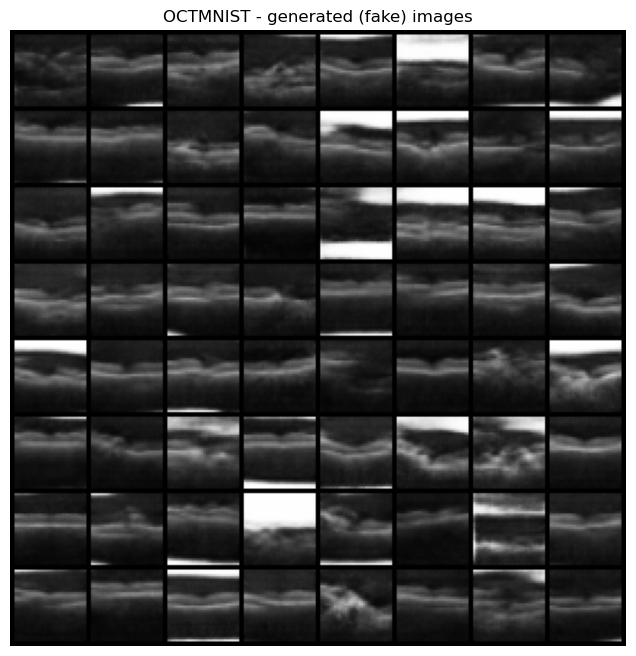

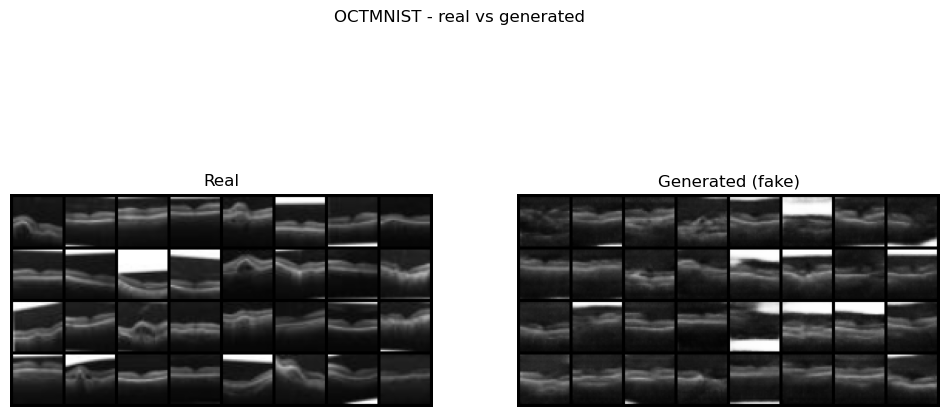

OCTMNIST DCGAN FID (lower is better): 43.70


In [17]:
# build the Inception feature extractor once and reuse it for every FID call
inception_feature_extractor = InceptionFeatureExtractor(COMPUTE_DEVICE)


def convert_tanh_range_to_unit_range(images_tanh_range: Tensor) -> Tensor:
    """Map images from the [-1, 1] tanh range to the [0, 1] range FID expects."""
    return (images_tanh_range.clamp(-1, 1) + 1.0) / 2.0


# generated images for the grid and for FID
octmnist_fake_images = generate_dcgan_image_batch(octmnist_generator, FID_SAMPLE_COUNT)
plot_image_sample_grid(octmnist_fake_images[:64], "OCTMNIST - generated (fake) images",
    os.path.join(RESULTS_DIRECTORY, "octmnist_fake_samples.png"))

# side-by-side real vs fake
octmnist_real_for_display = preprocess_grayscale_images_to_tensor(octmnist_images_uint8[:32])
plot_real_versus_fake_grids(octmnist_real_for_display, octmnist_fake_images[:32],
    "OCTMNIST - real vs generated", os.path.join(RESULTS_DIRECTORY, "octmnist_real_vs_fake.png"))

# a separate real sample for FID, preprocessed the same way
octmnist_fid_real_indices = np.random.permutation(len(octmnist_images_uint8))[:FID_SAMPLE_COUNT]
octmnist_real_for_fid = convert_tanh_range_to_unit_range(
    preprocess_grayscale_images_to_tensor(octmnist_images_uint8[octmnist_fid_real_indices]))
octmnist_fake_for_fid = convert_tanh_range_to_unit_range(octmnist_fake_images)

octmnist_fid_score = compute_frechet_inception_distance(
    octmnist_real_for_fid, octmnist_fake_for_fid, inception_feature_extractor)
print(f"OCTMNIST DCGAN FID (lower is better): {octmnist_fid_score:.2f}")

## Conditional GAN (extension)

A conditional DCGAN lets me ask for a specific class instead of just sampling something random. I embed the label and then (a) concatenate it with the latent vector for the generator, and (b) turn it into an extra input channel for the discriminator.

The naive version of this collapsed on me: the discriminator loss dropped to zero, the generator loss blew up, and the output was just noise. Three fairly standard fixes sorted it out - one-sided label smoothing (real target 0.9), a two time-scale update rule (TTUR) so the discriminator learns more slowly, and class-balanced sampling so the minority classes actually get seen during training.

In [18]:
class ConditionalDcganGenerator(nn.Module):
    """Class-conditioned DCGAN generator (32x32, single channel)."""

    def __init__(self, number_of_classes: int, latent_dimension: int = DCGAN_LATENT_DIMENSION,
                 feature_maps: int = 64, image_channels: int = 1, label_embedding_dimension: int = 50) -> None:
        super().__init__()
        self.label_embedding = nn.Embedding(number_of_classes, label_embedding_dimension)
        self.network = _build_dcgan_generator_stack(latent_dimension + label_embedding_dimension, feature_maps, image_channels)

    def forward(self, latent_noise: Tensor, class_labels: Tensor) -> Tensor:
        label_vector = self.label_embedding(class_labels).unsqueeze(-1).unsqueeze(-1)  # (N, emb, 1, 1)
        conditioned_input = torch.cat([latent_noise, label_vector], dim=1)
        return self.network(conditioned_input)


class ConditionalDcganDiscriminator(nn.Module):
    """Class-conditioned DCGAN discriminator (label injected as an extra channel)."""

    def __init__(self, number_of_classes: int, feature_maps: int = 64, image_channels: int = 1, image_size: int = 32) -> None:
        super().__init__()
        self.image_size = image_size
        self.label_embedding = nn.Embedding(number_of_classes, image_size * image_size)
        self.network = _build_dcgan_discriminator_stack(image_channels + 1, feature_maps)

    def forward(self, images: Tensor, class_labels: Tensor) -> Tensor:
        label_map = self.label_embedding(class_labels).view(-1, 1, self.image_size, self.image_size)
        conditioned_input = torch.cat([images, label_map], dim=1)
        return self.network(conditioned_input).view(-1, 1)


def train_conditional_dcgan(
    generator: ConditionalDcganGenerator,
    discriminator: ConditionalDcganDiscriminator,
    dataloader: DataLoader,
    number_of_epochs: int,
    number_of_classes: int,
    latent_dimension: int = DCGAN_LATENT_DIMENSION,
    generator_learning_rate: float = 2e-4,
    discriminator_learning_rate: float = 1e-4,
    adam_betas: tuple[float, float] = (0.5, 0.999),
    device: torch.device = COMPUTE_DEVICE,
    real_label_smoothing: float = 0.9,
) -> tuple[list[float], list[float]]:
    """Train the conditional DCGAN; dataloader must yield (images, labels).

    Three stabilisers prevent the discriminator-collapse (D loss -> 0, G loss -> inf,
    noise output) seen with a naive conditional DCGAN:
      * One-sided label smoothing (real target = 0.9) floors the discriminator loss.
      * TTUR: the discriminator learns slower than the generator
        (``discriminator_learning_rate`` < ``generator_learning_rate``) so it cannot
        overpower the generator early on.
      * The caller supplies a class-balanced dataloader so every class is learned.
    """
    generator.apply(initialise_dcgan_weights)
    discriminator.apply(initialise_dcgan_weights)
    generator_optimizer = torch.optim.Adam(generator.parameters(), lr=generator_learning_rate, betas=adam_betas)
    discriminator_optimizer = torch.optim.Adam(discriminator.parameters(), lr=discriminator_learning_rate, betas=adam_betas)
    binary_cross_entropy = nn.BCEWithLogitsLoss()

    discriminator_loss_history: list[float] = []
    generator_loss_history: list[float] = []

    for epoch_index in range(1, number_of_epochs + 1):
        for real_image_batch, real_label_batch in dataloader:
            real_image_batch = real_image_batch.to(device)
            real_label_batch = real_label_batch.to(device).long()
            current_batch_size = real_image_batch.size(0)

            # discriminator update (real target smoothed to 0.9)
            latent_noise = torch.randn(current_batch_size, latent_dimension, 1, 1, device=device)
            sampled_labels = torch.randint(0, number_of_classes, (current_batch_size,), device=device)
            generated_images = generator(latent_noise, sampled_labels).detach()
            real_logits = discriminator(real_image_batch, real_label_batch)
            fake_logits = discriminator(generated_images, sampled_labels)
            discriminator_loss = (
                binary_cross_entropy(real_logits, torch.full_like(real_logits, real_label_smoothing))
                + binary_cross_entropy(fake_logits, torch.zeros_like(fake_logits))
            )
            discriminator_optimizer.zero_grad(set_to_none=True)
            discriminator_loss.backward()
            discriminator_optimizer.step()

            # ---- Generator update (target = 1.0, non-saturating) ---- #
            latent_noise = torch.randn(current_batch_size, latent_dimension, 1, 1, device=device)
            sampled_labels = torch.randint(0, number_of_classes, (current_batch_size,), device=device)
            generator_logits = discriminator(generator(latent_noise, sampled_labels), sampled_labels)
            generator_loss = binary_cross_entropy(generator_logits, torch.ones_like(generator_logits))
            generator_optimizer.zero_grad(set_to_none=True)
            generator_loss.backward()
            generator_optimizer.step()

            discriminator_loss_history.append(float(discriminator_loss.item()))
            generator_loss_history.append(float(generator_loss.item()))
        print(f"[cGAN] epoch {epoch_index:>3}/{number_of_epochs} | D={discriminator_loss.item():.4f} | G={generator_loss.item():.4f}")

    return discriminator_loss_history, generator_loss_history

[cGAN] epoch   1/40 | D=0.6602 | G=3.0343
[cGAN] epoch   2/40 | D=0.9666 | G=1.8315
[cGAN] epoch   3/40 | D=0.5378 | G=2.9345
[cGAN] epoch   4/40 | D=0.4481 | G=4.1290
[cGAN] epoch   5/40 | D=0.7199 | G=2.0074
[cGAN] epoch   6/40 | D=1.9453 | G=0.9483
[cGAN] epoch   7/40 | D=1.3154 | G=0.9649
[cGAN] epoch   8/40 | D=1.4172 | G=0.8270
[cGAN] epoch   9/40 | D=1.3770 | G=0.9056
[cGAN] epoch  10/40 | D=1.3366 | G=1.0073
[cGAN] epoch  11/40 | D=1.3622 | G=0.9110
[cGAN] epoch  12/40 | D=1.4105 | G=0.9229
[cGAN] epoch  13/40 | D=1.4052 | G=0.9360
[cGAN] epoch  14/40 | D=1.3805 | G=1.0004
[cGAN] epoch  15/40 | D=1.4135 | G=0.9950
[cGAN] epoch  16/40 | D=1.3014 | G=1.0356
[cGAN] epoch  17/40 | D=1.3820 | G=0.9907
[cGAN] epoch  18/40 | D=1.3545 | G=0.9684
[cGAN] epoch  19/40 | D=1.2908 | G=1.0729
[cGAN] epoch  20/40 | D=1.3929 | G=1.0280
[cGAN] epoch  21/40 | D=1.2965 | G=1.0905
[cGAN] epoch  22/40 | D=1.2202 | G=1.1471
[cGAN] epoch  23/40 | D=1.2102 | G=1.1590
[cGAN] epoch  24/40 | D=1.0392 | G

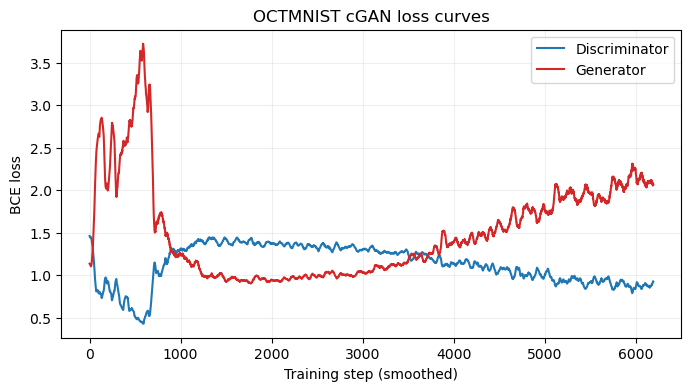

In [19]:
configure_global_reproducibility()
number_of_octmnist_classes = len(octmnist_class_labels)

# Reuse the same subset, this time carrying labels for conditioning.
# Class-balanced sampling counters the OCTMNIST imbalance so every class is learned.
octmnist_label_tensor = torch.from_numpy(octmnist_labels[octmnist_subset_indices]).long()
conditional_dataloader = build_class_balanced_dataloader(octmnist_image_tensor, octmnist_label_tensor, IMAGE_GAN_BATCH_SIZE)

conditional_generator = maybe_data_parallel(ConditionalDcganGenerator(number_of_octmnist_classes).to(COMPUTE_DEVICE))
conditional_discriminator = maybe_data_parallel(ConditionalDcganDiscriminator(number_of_octmnist_classes).to(COMPUTE_DEVICE))

conditional_d_losses, conditional_g_losses = train_conditional_dcgan(
    conditional_generator, conditional_discriminator, conditional_dataloader,
    number_of_epochs=IMAGE_GAN_EPOCHS, number_of_classes=number_of_octmnist_classes)
plot_adversarial_loss_curves(conditional_d_losses, conditional_g_losses,
    "OCTMNIST cGAN loss curves", os.path.join(RESULTS_DIRECTORY, "octmnist_cgan_loss_curves.png"))

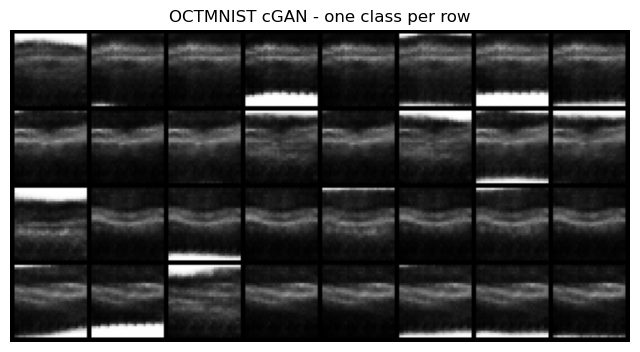

In [20]:
# generate a fixed number per class to show the conditioning works
@torch.no_grad()
def generate_conditional_class_grid(generator: ConditionalDcganGenerator, number_of_classes: int,
                                    images_per_class: int = 8, latent_dimension: int = DCGAN_LATENT_DIMENSION,
                                    device: torch.device = COMPUTE_DEVICE) -> Tensor:
    """Return an (number_of_classes * images_per_class, 1, 32, 32) tensor, row = class."""
    generator.eval()
    per_class_batches = []
    for class_index in range(number_of_classes):
        latent_noise = torch.randn(images_per_class, latent_dimension, 1, 1, device=device)
        class_labels = torch.full((images_per_class,), class_index, dtype=torch.long, device=device)
        per_class_batches.append(generator(latent_noise, class_labels).cpu())
    generator.train()
    return torch.cat(per_class_batches, dim=0)


conditional_class_grid = generate_conditional_class_grid(conditional_generator, number_of_octmnist_classes)
plot_image_sample_grid(conditional_class_grid, "OCTMNIST cGAN - one class per row",
    os.path.join(RESULTS_DIRECTORY, "octmnist_cgan_per_class.png"), grid_row_count=8)

## Reflection

The fakes broadly look like real scans. The generator picks up the bright curved retinal band sitting over a darker background, and the samples are varied rather than all the same, so it hasn't collapsed. The main weaknesses are softness and some smeared sub-layers, which lines up with the FID of 43.70 for a 32x32 DCGAN trained for 40 epochs on single-channel medical images.

The cGAN extension adds the per-class control I wanted, and the class-balanced sampling deals with OCTMNIST's roughly 6:1 imbalance. The visual difference between classes stays fairly subtle, which honestly matches how similar these scans look even in the real data.

The biggest limitation I'd flag is that the discriminator only ever learns to separate real from fake - it never learns whether an image is anatomically plausible. So the generator can put a bright patch or a layer boundary somewhere with no basis in real anatomy, as long as it's statistically convincing enough to fool D. That's fine for augmentation or teaching, but I wouldn't feed synthetic scans into anything doing an actual diagnosis, and if I trained a classifier on a real+synthetic mix I'd want to re-check it on real-only data.

## A note on generating ducks

The brief asks us to say something about using GANs to generate ducks, which sounds like a bit of a joke sitting next to retinal scans, but it actually gets at something real about what this model does and doesn't understand. The DCGAN in this part has no idea it's looking at eyes. All it ever sees is a big pile of 32x32 grayscale arrays, and it learns the statistics of whatever is in that pile. If I deleted the OCTMNIST loading cell and dropped in a folder of duck photos resized to the same shape, the generator, discriminator, loss and training loop would all run completely unchanged, and I'd get synthetic ducks out the other end. The architecture is totally content-agnostic - nothing in it is "about" medicine.

That's worth spelling out because it cuts both ways. It's exactly why the same handful of tricks (the DCGAN layout, BatchNorm, the [-1, 1] / Tanh setup, the label smoothing) carry over so easily from doodles to medical images without me having to rethink anything. But it's also the reason I keep insisting the synthetic scans can't be trusted on their own. The model will happily reproduce a bright retinal band with the exact same confidence it would draw a duck's beak, and it has no concept of anatomy sitting behind either one. A duck that comes out slightly wrong is just funny; a retina that comes out slightly wrong but looks convincing is a genuine problem the moment it gets anywhere near a diagnosis. So the "ducks" framing is really a reminder that "realistic" to a GAN only means "statistically similar to the training data", not "correct" - and that gap is the thing to keep in mind whenever the output is going to be used for something that matters.

# Part 2.2 - Cybersecurity: synthetic traffic with CICIDS 2017

In CICIDS 2017 each network flow is stored as around 78 numeric features rather than an image, so a convolutional DCGAN doesn't fit here. Instead I use a fully-connected GAN that follows the same DCGAN training recipe I used above: adversarial `BCEWithLogitsLoss`, BatchNorm in the generator, a LeakyReLU discriminator, Adam, and one-sided label smoothing. The convolutional layers are the part that's specific to images, so I drop those and use dense layers, but I keep the rest of the recipe since the brief asks for feature vectors.

**My plan, following the brief:** combine the per-day CSVs and look at the class balance, then narrow down to the Wednesday file (BENIGN vs DoS), train the feature-vector GAN on it, and compare real vs synthetic using PCA and t-SNE.

> **A note on the label:** the brief says "DDoS", but Wednesday's attacks are actually single-source DoS (Hulk, GoldenEye, slowloris, Slowhttptest). I've stuck with the named day and treated it as BENIGN vs DoS, and I'm noting the mismatch here so the marker knows it was deliberate rather than a mistake.

## Getting the CSV files

The cell below pulls the CICIDS 2017 dataset (the eight per-day CSVs) automatically from Kaggle using `kagglehub`: https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset

Because this is a public dataset, **no Kaggle account or API token is needed** - `kagglehub` fetches it directly and caches it locally (about 1 GB), so re-runs just reuse the copy already on disk. You can see from the printed path that it loads the eight CSVs straight out of the local `kagglehub` cache.

In [21]:
!pip install -q kagglehub
import os, contextlib, pandas as pd, kagglehub
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

CICIDS_CSV_FILES = [
    "Monday-WorkingHours.pcap_ISCX.csv", "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv", "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv", "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv", "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
]

with open(os.devnull, "w") as _d, contextlib.redirect_stdout(_d), contextlib.redirect_stderr(_d):
    CICIDS_DIR = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")
file_index = {f: os.path.join(dp, f) for dp, _, fs in os.walk(CICIDS_DIR) for f in fs}
cicids_csv_paths = [file_index.get(name) for name in CICIDS_CSV_FILES]

missing_files = [name for name, path in zip(CICIDS_CSV_FILES, cicids_csv_paths) if path is None]
if missing_files:
    raise FileNotFoundError(f"CICIDS CSV files not found under {CICIDS_DIR}: {missing_files}")

print(f"Using {len(cicids_csv_paths)} CICIDS 2017 CSV files")

Using 8 CICIDS 2017 CSV files


## Combine every day's file and explore

Following the brief, I merge all the day files into one frame (tagging each row with its `SourceDay`) and then look around: the overall class balance, how many flows there are per day, the feature count, how many Inf/NaN values will need cleaning, and the attack fraction on each day. The combined frame comes to about 2.83M flows across 80 columns, and BENIGN outnumbers everything else by a huge margin, so the class-count plot uses a log scale to stay readable. I also cast the numeric columns to float32 to keep that large frame in memory.

In [ ]:
DAY_NAMES = ("Monday", "Tuesday", "Wednesday", "Thursday", "Friday")

def day_from_filename(path):
    """Return the weekday embedded in a CICIDS filename, or 'Unknown'."""
    lowered = os.path.basename(path).lower()
    for day in DAY_NAMES:
        if day.lower() in lowered:
            return day
    return "Unknown"

collected = []
for path in cicids_csv_paths:
    frame = pd.read_csv(path, low_memory=False)
    frame.columns = frame.columns.str.strip()
    keep_cols = [column for column in frame.columns if not column.startswith("Unnamed")]
    frame = frame[keep_cols]
    if "Label" not in frame.columns:
        print(f"  skipping {os.path.basename(path)} (no Label column)")
        continue
    frame["Label"] = frame["Label"].astype(str).str.strip()
    frame["SourceDay"] = day_from_filename(path)
    numeric_here = frame.select_dtypes(include=[np.number]).columns
    frame[numeric_here] = frame[numeric_here].astype(np.float32)
    collected.append(frame)
if not collected:
    raise ValueError("No CICIDS day files with a Label column were found - check the dataset was added.")
# join="inner" keeps only columns common to all files, so a schema mismatch can't add
# all-NaN phantom columns that dropna() would later use to wipe good rows.
combined_frame = pd.concat(collected, ignore_index=True, join="inner")
del collected
print(f"Combined dataset: {combined_frame.shape[0]:,} flows x {combined_frame.shape[1]} columns")


In [ ]:
# class balance across all days, and flows per day
class_counts = combined_frame["Label"].value_counts()
day_counts = combined_frame["SourceDay"].value_counts()
print("Overall class distribution (all days):")
print(class_counts)
fig, (ax_class, ax_day) = plt.subplots(1, 2, figsize=(15, 4))
ax_class.bar(class_counts.index.astype(str), class_counts.to_numpy(), color="#1f77b4")
ax_class.set_yscale("log")
ax_class.set_title("Class distribution across all days (log scale)")
ax_class.set_ylabel("flow count (log)")
ax_class.tick_params(axis="x", rotation=40)
ax_day.bar(day_counts.index.astype(str), day_counts.to_numpy(), color="#2ca02c")
ax_day.set_title("Flows per day")
ax_day.set_ylabel("flow count")
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIRECTORY, "cicids_class_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# feature overview and a quick data-quality check
numeric_feature_columns = [column for column in combined_frame.columns
                           if column not in ("Label", "SourceDay")
                           and np.issubdtype(combined_frame[column].dtype, np.number)]
print(f"Numeric feature count: {len(numeric_feature_columns)}")
print("First 12 features:", numeric_feature_columns[:12])
_quality_block = combined_frame[numeric_feature_columns].to_numpy()
print(f"Infinite values across features: {int(np.isinf(_quality_block).sum()):,}")
print(f"Missing (NaN) values across features: {int(np.isnan(_quality_block).sum()):,}")
del _quality_block
# attack fraction per day (which days are attack-heavy)
attack_flag = combined_frame["Label"].ne("BENIGN").astype(int)
attack_fraction_per_day = attack_flag.groupby(combined_frame["SourceDay"]).mean().sort_values()
print("Fraction of attack flows per day:")
print(attack_fraction_per_day)


## Narrowing to Wednesday (BENIGN vs DoS) and preprocessing

As the brief asks, I train the GAN on the Wednesday file only, pulled straight out of the combined frame. I drop the Inf/NaN rows, build a binary BENIGN-vs-DoS target, and keep the numeric features, standardise them, and then clip to +/-5 sigma. The clipping is there because CICIDS has some very extreme outliers, and without it those spikes can destabilise training.

In [25]:
wednesday_frame = combined_frame[combined_frame["SourceDay"] == "Wednesday"].copy()
if wednesday_frame.empty:
    raise ValueError("No Wednesday rows found in the combined dataset - check the file names.")

print("Wednesday class balance:")
print(wednesday_frame["Label"].value_counts())

# drop the Inf/NaN rows the flow features introduce
wednesday_frame = wednesday_frame.replace([np.inf, -np.inf], np.nan).dropna()
if wednesday_frame.empty:
    raise ValueError("Wednesday data is empty after Inf/NaN cleaning - unexpected for this dataset.")

# binary target: BENIGN (0) vs any DoS (1)
attack_indicator = (wednesday_frame["Label"] != "BENIGN").astype(int).to_numpy()

# numeric features only; drop the label and day columns so nothing leaks the target
feature_frame = (
    wednesday_frame.drop(columns=["Label", "SourceDay"], errors="ignore")
    .select_dtypes(include=[np.number])
    .astype(np.float32)
)
feature_names = list(feature_frame.columns)
feature_matrix = feature_frame.to_numpy()
print(f"Feature vectors: {feature_matrix.shape[0]} rows x {feature_matrix.shape[1]} features")

# standardise, then clip extreme outliers to +/-5 sigma
feature_scaler = StandardScaler().fit(feature_matrix)
scaled_features = np.clip(feature_scaler.transform(feature_matrix), -5.0, 5.0).astype(np.float32)

Wednesday class balance:
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64
Feature vectors: 691406 rows x 78 features


In [26]:
configure_global_reproducibility()

# subsample rows to keep training and t-SNE manageable
cicids_max_training_rows = 4000 if QUICK_SMOKE_TEST else 20000
cicids_row_indices = np.random.permutation(scaled_features.shape[0])[:cicids_max_training_rows]

cicids_training_features = torch.tensor(scaled_features[cicids_row_indices], dtype=torch.float32)
cicids_feature_dimension = cicids_training_features.shape[1]
cicids_dataloader = DataLoader(
    TensorDataset(cicids_training_features), batch_size=256, shuffle=True, drop_last=True, num_workers=2
)
print(f"Training feature-vector GAN on {cicids_training_features.shape[0]} rows x {cicids_feature_dimension} features")

Training feature-vector GAN on 20000 rows x 78 features


## The feature-vector GAN (dense layers, DCGAN recipe)

The generator turns latent noise into a full feature vector using BatchNorm + ReLU, with a plain linear output layer because the standardised features aren't bounded to any fixed range (so no Tanh here). The discriminator is a dense LeakyReLU network with dropout that scores a vector as either real or synthetic.

In [ ]:
CICIDS_LATENT_DIMENSION = 32

class TabularFeatureGenerator(nn.Module):
    """Latent noise -> a synthetic (standardised) CICIDS feature vector, linear output."""
    def __init__(self, latent_dimension, feature_dimension):
        super().__init__()
        widths = [latent_dimension, 160, 320]
        blocks = []
        for in_dim, out_dim in zip(widths[:-1], widths[1:]):
            blocks += [nn.Linear(in_dim, out_dim), nn.BatchNorm1d(out_dim), nn.ReLU(inplace=True)]
        blocks.append(nn.Linear(widths[-1], feature_dimension))
        self.network = nn.Sequential(*blocks)

    def forward(self, latent_noise):
        return self.network(latent_noise)

class TabularFeatureDiscriminator(nn.Module):
    """Scores a feature vector real (high) or synthetic (low) as a raw logit."""
    def __init__(self, feature_dimension):
        super().__init__()
        widths = [feature_dimension, 320, 160]
        blocks = []
        for in_dim, out_dim in zip(widths[:-1], widths[1:]):
            blocks += [nn.Linear(in_dim, out_dim), nn.LeakyReLU(0.2, inplace=True), nn.Dropout(0.3)]
        blocks.append(nn.Linear(widths[-1], 1))
        self.network = nn.Sequential(*blocks)

    def forward(self, feature_vectors):
        return self.network(feature_vectors)


In [ ]:
def train_feature_vector_gan(
    dataloader,
    feature_dimension,
    number_of_epochs,
    latent_dimension=CICIDS_LATENT_DIMENSION,
    learning_rate=2e-4,
    adam_betas=(0.5, 0.999),
    real_label_smoothing=0.9,
    device=COMPUTE_DEVICE,
):
    """Train the feature-vector GAN using the DCGAN recipe (BCE + one-sided smoothing).
    The two adversarial updates are factored into small closures so the epoch loop reads
    as just 'do a critic step, then a generator step'."""
    generator = TabularFeatureGenerator(latent_dimension, feature_dimension).to(device)
    discriminator = TabularFeatureDiscriminator(feature_dimension).to(device)
    optimiser_g = torch.optim.Adam(generator.parameters(), lr=learning_rate, betas=adam_betas)
    optimiser_d = torch.optim.Adam(discriminator.parameters(), lr=learning_rate, betas=adam_betas)
    bce = nn.BCEWithLogitsLoss()

    def sample_noise(rows):
        return torch.randn(rows, latent_dimension, device=device)

    def discriminator_step(real_batch):
        rows = real_batch.size(0)
        synthetic = generator(sample_noise(rows)).detach()
        loss = (bce(discriminator(real_batch), torch.full((rows, 1), real_label_smoothing, device=device))
                + bce(discriminator(synthetic), torch.zeros(rows, 1, device=device)))
        optimiser_d.zero_grad(set_to_none=True); loss.backward(); optimiser_d.step()
        return float(loss.item())

    def generator_step(rows):
        loss = bce(discriminator(generator(sample_noise(rows))), torch.ones(rows, 1, device=device))
        optimiser_g.zero_grad(set_to_none=True); loss.backward(); optimiser_g.step()
        return float(loss.item())

    discriminator_loss_history, generator_loss_history = [], []
    for epoch_index in range(1, number_of_epochs + 1):
        for (real_feature_batch,) in dataloader:
            real_feature_batch = real_feature_batch.to(device)
            discriminator_loss_history.append(discriminator_step(real_feature_batch))
            generator_loss_history.append(generator_step(real_feature_batch.size(0)))
        if epoch_index == 1 or epoch_index % 10 == 0:
            print(f"epoch {epoch_index:>3}/{number_of_epochs} | "
                  f"D={discriminator_loss_history[-1]:.4f} | G={generator_loss_history[-1]:.4f}")
    return generator, discriminator_loss_history, generator_loss_history


epoch   1/60 | D=1.2509 | G=0.8207
epoch  10/60 | D=1.2502 | G=0.9827
epoch  20/60 | D=1.1564 | G=1.1634
epoch  30/60 | D=1.1000 | G=1.2913
epoch  40/60 | D=1.0737 | G=1.2869
epoch  50/60 | D=1.0694 | G=1.3683
epoch  60/60 | D=1.0799 | G=1.3983


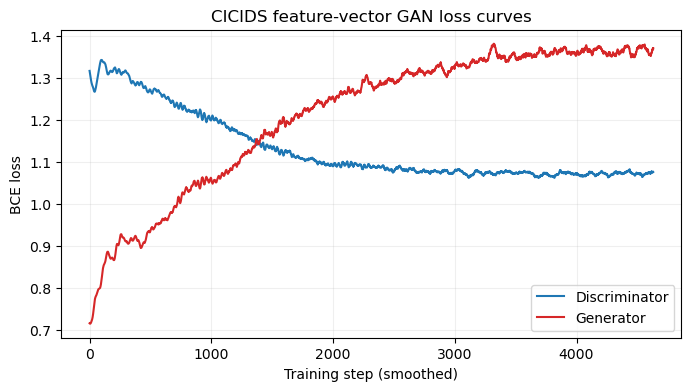

In [29]:
configure_global_reproducibility()
cicids_epochs = 5 if QUICK_SMOKE_TEST else 60
cicids_generator, cicids_discriminator_losses, cicids_generator_losses = train_feature_vector_gan(
    cicids_dataloader, cicids_feature_dimension, number_of_epochs=cicids_epochs
)
plot_adversarial_loss_curves(
    cicids_discriminator_losses, cicids_generator_losses,
    "CICIDS feature-vector GAN loss curves", os.path.join(RESULTS_DIRECTORY, "cicids_loss_curves.png"),
)

## Comparing real vs synthetic (PCA and t-SNE)

I project the real and generated feature vectors down to 2D to compare them. PCA gives a quick linear view (real BENIGN, real DoS and synthetic each coloured separately), and t-SNE shows the more local structure. The idea is simple: if the synthetic cloud lands on top of the real points, the GAN has picked up the distribution.

In [ ]:
@torch.no_grad()
def generate_synthetic_feature_vectors(generator, count, latent_dimension=CICIDS_LATENT_DIMENSION, device=COMPUTE_DEVICE):
    """Draw synthetic feature vectors from the trained generator."""
    generator.eval()
    latent_noise = torch.randn(count, latent_dimension, device=device)
    synthetic = generator(latent_noise).cpu().numpy()
    generator.train()
    return synthetic

cicids_comparison_sample = 800 if QUICK_SMOKE_TEST else 2000
real_comparison_indices = np.random.permutation(scaled_features.shape[0])[:cicids_comparison_sample]
real_comparison_features = scaled_features[real_comparison_indices]
real_comparison_labels = attack_indicator[real_comparison_indices]
synthetic_comparison_features = generate_synthetic_feature_vectors(cicids_generator, cicids_comparison_sample)

def render_projection(ax, layers, title, axis_labels):
    """Scatter a dict of {name: (xy_array, colour)} onto one axis and label it."""
    for name, (coords, colour) in layers.items():
        ax.scatter(coords[:, 0], coords[:, 1], s=8, alpha=0.4, label=name, color=colour)
    ax.set_title(title)
    ax.set_xlabel(axis_labels[0])
    ax.set_ylabel(axis_labels[1])
    ax.legend(); ax.grid(alpha=0.2)

pca_projection = PCA(n_components=2).fit(real_comparison_features)
real_pca = pca_projection.transform(real_comparison_features)
synthetic_pca = pca_projection.transform(synthetic_comparison_features)
is_benign = real_comparison_labels == 0
fig, ax = plt.subplots(figsize=(7, 6))
render_projection(ax, {
    "Real BENIGN": (real_pca[is_benign], "#1f77b4"),
    "Real DoS": (real_pca[~is_benign], "#2ca02c"),
    "Synthetic": (synthetic_pca, "#d62728"),
}, "CICIDS - PCA of real vs synthetic feature vectors", ("PC 1", "PC 2"))
fig.savefig(os.path.join(RESULTS_DIRECTORY, "cicids_pca.png"), dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
tsne_inputs = np.vstack([real_comparison_features, synthetic_comparison_features])
tsne_embedding = TSNE(n_components=2, perplexity=30, init="pca", random_state=GLOBAL_RANDOM_SEED).fit_transform(tsne_inputs)
real_tsne = tsne_embedding[:cicids_comparison_sample]
synthetic_tsne = tsne_embedding[cicids_comparison_sample:]
fig, ax = plt.subplots(figsize=(7, 6))
render_projection(ax, {
    "Real": (real_tsne, "#1f77b4"),
    "Synthetic": (synthetic_tsne, "#d62728"),
}, "CICIDS - t-SNE of real vs synthetic feature vectors", ("t-SNE 1", "t-SNE 2"))
fig.savefig(os.path.join(RESULTS_DIRECTORY, "cicids_tsne.png"), dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
def moment_gaps(real, fake):
    """Mean absolute per-feature gaps in mean and std between real and synthetic sets."""
    mean_gap = float(np.abs(real.mean(0) - fake.mean(0)).mean())
    std_gap = float(np.abs(real.std(0) - fake.std(0)).mean())
    return mean_gap, std_gap

mean_gap, std_gap = moment_gaps(real_comparison_features, synthetic_comparison_features)
print(f"Mean |mean-gap| across features (standardised): {mean_gap:.4f}")
print(f"Mean |std-gap|  across features (standardised): {std_gap:.4f}")
print("(Values near 0 mean the synthetic feature statistics match the real ones.)")


## How well does the synthetic traffic match?

Reading the PCA and t-SNE together, the synthetic feature vectors sit right on top of the dense BENIGN region and push part of the way into the DoS clusters, without fully reproducing their separate structure. The numbers back up what I'm seeing: an average absolute gap of 0.1057 on the per-feature means and 0.1975 on the standard deviations (both in standardised units). So the generator does a good job of matching where most of the traffic lives and what the typical feature values are, but it comes out smoother than the real data and doesn't reach the DoS tails. That's the usual outcome for a plain unconditional GAN on heavy-tailed, partly-binary network features.

## All days and generalisation (extension)

For the extra-credit part I train the same feature-vector GAN on the full CICIDS 2017 set (all days, every attack type) instead of Wednesday alone, to see how well it spreads across the different attack families. I colour the real points by family in the PCA/t-SNE plots, so it's easy to tell whether the synthetic samples cover the whole multi-modal structure or just fall back onto BENIGN.

In [33]:
def map_attack_family(label):
    """Collapse the fine-grained CICIDS labels into coarse families for colouring."""
    if label == "BENIGN":
        return "BENIGN"
    if label.startswith("DoS"):
        return "DoS"
    if label == "DDoS":
        return "DDoS"
    if label == "PortScan":
        return "PortScan"
    if label.startswith("Web Attack"):
        return "Web Attack"
    if label == "Bot":
        return "Bot"
    if label.startswith(("FTP", "SSH")):
        return "Brute Force"
    if label == "Infiltration":
        return "Infiltration"
    if label == "Heartbleed":
        return "Heartbleed"
    return "Other"


configure_global_reproducibility()

# clean the full combined dataset (all days) and build its feature matrix
full_frame = combined_frame.replace([np.inf, -np.inf], np.nan).dropna()
full_attack_families = full_frame["Label"].map(map_attack_family).to_numpy()
full_feature_frame = (
    full_frame.drop(columns=["Label", "SourceDay"], errors="ignore")
    .select_dtypes(include=[np.number])
    .astype(np.float32)
)
full_feature_matrix = full_feature_frame.to_numpy()
print(f"Full dataset feature vectors: {full_feature_matrix.shape[0]:,} rows x {full_feature_matrix.shape[1]} features")

# standardise + clip with a scaler fit on the full dataset (different scale to Wednesday)
full_feature_scaler = StandardScaler().fit(full_feature_matrix)
full_scaled_features = np.clip(full_feature_scaler.transform(full_feature_matrix), -5.0, 5.0).astype(np.float32)
del full_frame, full_feature_frame, full_feature_matrix   # free memory; arrays retained below

# subsample rows from all days for training
full_max_training_rows = 6000 if QUICK_SMOKE_TEST else 30000
full_row_indices = np.random.permutation(full_scaled_features.shape[0])[:full_max_training_rows]
full_training_features = torch.tensor(full_scaled_features[full_row_indices], dtype=torch.float32)
full_dataloader = DataLoader(
    TensorDataset(full_training_features), batch_size=256, shuffle=True, drop_last=True, num_workers=2
)
print(f"Training the feature-vector GAN on {full_training_features.shape[0]} rows sampled from all days")

Full dataset feature vectors: 2,827,876 rows x 78 features
Training the feature-vector GAN on 30000 rows sampled from all days


epoch   1/60 | D=1.3380 | G=0.8500
epoch  10/60 | D=1.1779 | G=1.0305
epoch  20/60 | D=1.1446 | G=1.1620
epoch  30/60 | D=1.1569 | G=1.2276
epoch  40/60 | D=1.1002 | G=1.2077
epoch  50/60 | D=1.0816 | G=1.2401
epoch  60/60 | D=1.0985 | G=1.2358


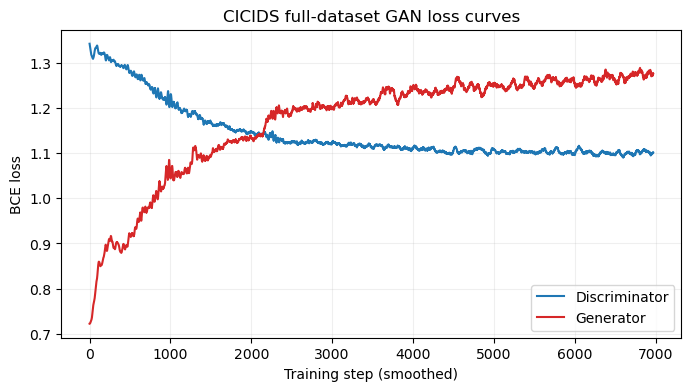

In [34]:
configure_global_reproducibility()
full_dataset_epochs = 5 if QUICK_SMOKE_TEST else 60
full_generator, full_discriminator_losses, full_generator_losses = train_feature_vector_gan(
    full_dataloader, full_training_features.shape[1], number_of_epochs=full_dataset_epochs
)
plot_adversarial_loss_curves(
    full_discriminator_losses, full_generator_losses,
    "CICIDS full-dataset GAN loss curves", os.path.join(RESULTS_DIRECTORY, "cicids_full_loss_curves.png"),
)

In [ ]:
full_comparison_sample = 800 if QUICK_SMOKE_TEST else 2500
full_real_indices = np.random.permutation(full_scaled_features.shape[0])[:full_comparison_sample]
full_real_features = full_scaled_features[full_real_indices]
full_real_families = full_attack_families[full_real_indices]
full_synthetic_features = generate_synthetic_feature_vectors(full_generator, full_comparison_sample)
full_pca_projection = PCA(n_components=2).fit(full_real_features)
full_real_pca = full_pca_projection.transform(full_real_features)
full_synthetic_pca = full_pca_projection.transform(full_synthetic_features)
family_layers = {f"Real {family}": (full_real_pca[full_real_families == family], None)
                 for family in sorted(set(full_real_families))}
family_layers["Synthetic"] = (full_synthetic_pca, "black")
fig, ax = plt.subplots(figsize=(8, 6))
render_projection(ax, family_layers, "CICIDS full dataset - PCA (real by attack family vs synthetic)", ("PC 1", "PC 2"))
fig.savefig(os.path.join(RESULTS_DIRECTORY, "cicids_full_pca.png"), dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
full_tsne_inputs = np.vstack([full_real_features, full_synthetic_features])
full_tsne_embedding = TSNE(n_components=2, perplexity=30, init="pca", random_state=GLOBAL_RANDOM_SEED).fit_transform(full_tsne_inputs)
full_real_tsne = full_tsne_embedding[:full_comparison_sample]
full_synthetic_tsne = full_tsne_embedding[full_comparison_sample:]
tsne_family_layers = {f"Real {family}": (full_real_tsne[full_real_families == family], None)
                      for family in sorted(set(full_real_families))}
tsne_family_layers["Synthetic"] = (full_synthetic_tsne, "black")
fig, ax = plt.subplots(figsize=(8, 6))
render_projection(ax, tsne_family_layers, "CICIDS full dataset - t-SNE (real by attack family vs synthetic)", ("t-SNE 1", "t-SNE 2"))
fig.savefig(os.path.join(RESULTS_DIRECTORY, "cicids_full_tsne.png"), dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
full_mean_gap, full_std_gap = moment_gaps(full_real_features, full_synthetic_features)
print(f"Full-dataset mean |mean-gap|: {full_mean_gap:.4f} (Wednesday-only was {mean_gap:.4f})")
print(f"Full-dataset mean |std-gap| : {full_std_gap:.4f} (Wednesday-only was {std_gap:.4f})")
families_present, family_frequencies = np.unique(full_real_families, return_counts=True)
print("Attack families represented in the comparison sample:")
for family_name, family_frequency in zip(families_present, family_frequencies):
    print(f"  {family_name:>14}: {family_frequency}")


## Discussion (extension)

Trained on all days, the synthetic cloud leans towards BENIGN and the large attack blobs, while barely touching the rare families (Bot, Web Attack, Brute Force) - which makes sense, since those have very few samples to learn from in the first place. The mean-gap actually edges down a little (0.1017 vs 0.1057 on Wednesday), but the std-gap grows (0.2762 vs 0.1975): more data sharpens the averages, but the model still can't stretch far enough to cover the extra variance. So a single unconditional GAN doesn't generalise cleanly across many attack types - a conditional GAN, or one model per family, would help here.

One thing worth flagging: unlike an image, a synthetic feature vector has no easy visual sanity check for whether it's realistic. A fabricated "attack" that doesn't match how real attacks actually behave could teach a detector to expect the wrong thing, and a fabricated "benign" flow that drifts attack-like could raise false positives on real traffic. That's exactly why the PCA/t-SNE overlap and the per-feature gap numbers matter more here than a simple visual comparison would.

## A note on generating ducks

The same duck question shows up again for this part of the brief, and the underlying point is identical, but it lands a little differently on tabular data. This GAN's generator maps a noise vector to a roughly 78-number feature vector, and it has no more idea that those numbers are "network flows" than an image GAN would know its output was a "duck". If I swapped the CICIDS features for a set of duck images (with a convolutional version of the model), the training procedure wouldn't need a single conceptual change - it would just fit whatever distribution I handed it and generate from that.

What makes the traffic case trickier than an actual duck picture is that I can't just glance at a generated vector and see it's wrong. A dodgy duck is obvious at a glance; a dodgy flow with, say, a byte count that could never go with that flow duration is invisible until I actually check the numbers against each other. The model will cheerfully produce statistically plausible rows that might be physically impossible as real connections, because all it has ever learned is correlations between features, not the mechanics of an actual TCP session. That is the whole reason this part leans on the PCA/t-SNE overlap and the per-feature mean/std gaps instead of a visual comparison. With tabular security data the "does this even make sense?" check has to be done with statistics, because there's no picture to eyeball in the first place.

## TensorFlow/Keras setup (the `Model.fit` style)

For Part 2.3 I've written the Keras GAN in the higher-level, object-oriented way. The generator and discriminator are built with the functional API, then wrapped in a `keras.Model` subclass whose `train_step` does the adversarial update, and the whole thing is trained with `model.fit`. FID here uses a small `InceptionFidScorer` class. I did it this way partly to show a different style from the manual PyTorch training loops earlier in the notebook.

In [38]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

for _device in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(_device, True)
    except Exception:
        pass

KERAS_SEED = 2024
keras.utils.set_random_seed(KERAS_SEED)

KERAS_RESULTS_DIR = "results"
os.makedirs(KERAS_RESULTS_DIR, exist_ok=True)
import matplotlib.pyplot as plt
print("TensorFlow", tf.__version__, "| Keras", keras.__version__, "| ->", KERAS_RESULTS_DIR)

TensorFlow 2.21.0 | Keras 3.12.3 | -> results


In [39]:
# Functional-API DCGAN builders: Conv2DTranspose generator, strided-Conv2D discriminator.
def make_generator(latent_dim, base_filters=64, init_std=0.02):
    """Functional-API DCGAN generator: (latent,) -> (32, 32, 1) in [-1, 1]."""
    weight_init = keras.initializers.RandomNormal(stddev=init_std)
    latent = keras.Input(shape=(latent_dim,), name="latent")
    x = layers.Dense(4 * 4 * base_filters * 4, use_bias=False, kernel_initializer=weight_init)(latent)
    x = layers.Reshape((4, 4, base_filters * 4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    for filters in (base_filters * 2, base_filters):
        x = layers.Conv2DTranspose(filters, 4, strides=2, padding="same", use_bias=False,
                                   kernel_initializer=weight_init)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
    image = layers.Conv2DTranspose(1, 4, strides=2, padding="same", use_bias=False,
                                   activation="tanh", kernel_initializer=weight_init)(x)
    return keras.Model(latent, image, name="generator")


def make_discriminator(base_filters=64, init_std=0.02, dropout=0.3):
    """Functional-API DCGAN discriminator: (32, 32, 1) -> logit."""
    weight_init = keras.initializers.RandomNormal(stddev=init_std)
    image = keras.Input(shape=(32, 32, 1), name="image")
    x = image
    for i, filters in enumerate((base_filters, base_filters * 2, base_filters * 4)):
        x = layers.Conv2D(filters, 4, strides=2, padding="same", kernel_initializer=weight_init)(x)
        if i > 0:
            x = layers.BatchNormalization()(x)
        x = layers.LeakyReLU(0.2)(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(dropout)(x)
    logit = layers.Dense(1, kernel_initializer=weight_init)(x)
    return keras.Model(image, logit, name="discriminator")

In [40]:
# DCGAN as a keras.Model subclass, trained with model.fit rather than a manual loop.
class DcganModel(keras.Model):
    """DCGAN whose train_step does one discriminator update then one generator update."""

    def __init__(self, generator, discriminator, latent_dim, label_smoothing=0.9):
        super().__init__()
        self.generator = generator
        self.discriminator = discriminator
        self.latent_dim = latent_dim
        self.label_smoothing = label_smoothing
        self.d_loss_tracker = keras.metrics.Mean(name="d_loss")
        self.g_loss_tracker = keras.metrics.Mean(name="g_loss")

    @property
    def metrics(self):
        return [self.d_loss_tracker, self.g_loss_tracker]

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super().compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn

    def train_step(self, real_images):
        if isinstance(real_images, (tuple, list)):
            real_images = real_images[0]
        batch_size = tf.shape(real_images)[0]
        noise = tf.random.normal((batch_size, self.latent_dim))
        with tf.GradientTape() as d_tape, tf.GradientTape() as g_tape:
            generated = self.generator(noise, training=True)
            real_logits = self.discriminator(real_images, training=True)
            fake_logits = self.discriminator(generated, training=True)
            d_loss = (self.loss_fn(tf.ones_like(real_logits) * self.label_smoothing, real_logits)
                      + self.loss_fn(tf.zeros_like(fake_logits), fake_logits))
            g_loss = self.loss_fn(tf.ones_like(fake_logits), fake_logits)
        self.d_optimizer.apply_gradients(
            zip(d_tape.gradient(d_loss, self.discriminator.trainable_variables),
                self.discriminator.trainable_variables))
        self.g_optimizer.apply_gradients(
            zip(g_tape.gradient(g_loss, self.generator.trainable_variables),
                self.generator.trainable_variables))
        self.d_loss_tracker.update_state(d_loss)
        self.g_loss_tracker.update_state(g_loss)
        return {"d_loss": self.d_loss_tracker.result(), "g_loss": self.g_loss_tracker.result()}

    def synthesize(self, count):
        return self.generator(tf.random.normal((count, self.latent_dim)), training=False).numpy()


class EpochSampleLogger(keras.callbacks.Callback):
    """Callback that stores a fixed-noise sample grid at a few evenly spaced epochs."""

    def __init__(self, latent_dim, total_epochs, num_snapshots=5):
        super().__init__()
        self.fixed_noise = tf.random.normal((16, latent_dim))
        self.snapshot_epochs = sorted(set(int(round(v)) for v in np.linspace(1, total_epochs, num_snapshots)))
        self.snapshots = []

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) in self.snapshot_epochs:
            images = self.model.generator(self.fixed_noise, training=False).numpy()
            self.snapshots.append((epoch + 1, images))

In [41]:
# Class-based FID scorer plus a couple of image helpers.
class InceptionFidScorer:
    """FID from InceptionV3 pooled features (ImageNet weights)."""

    def __init__(self):
        self.backbone = keras.applications.InceptionV3(
            include_top=False, pooling="avg", weights="imagenet", input_shape=(299, 299, 3))

    def _embed(self, images_unit, batch=50):
        chunks = []
        for start in range(0, images_unit.shape[0], batch):
            block = tf.image.resize(tf.convert_to_tensor(images_unit[start:start + batch], tf.float32), (299, 299))
            block = tf.repeat(block, 3, axis=-1) if block.shape[-1] == 1 else block
            block = keras.applications.inception_v3.preprocess_input(block * 255.0)
            chunks.append(self.backbone(block, training=False).numpy())
        return np.concatenate(chunks, axis=0)

    def score(self, real_unit, fake_unit, eps=1e-6):
        from scipy import linalg
        real_embed, fake_embed = self._embed(real_unit), self._embed(fake_unit)
        mu_r, mu_f = real_embed.mean(0), fake_embed.mean(0)
        cov_r, cov_f = np.cov(real_embed, rowvar=False), np.cov(fake_embed, rowvar=False)
        covmean = linalg.sqrtm(cov_r.dot(cov_f))
        if isinstance(covmean, tuple):
            covmean = covmean[0]
        if not np.isfinite(covmean).all():
            covmean = linalg.sqrtm((cov_r + np.eye(cov_r.shape[0]) * eps).dot(cov_f + np.eye(cov_f.shape[0]) * eps))
            if isinstance(covmean, tuple):
                covmean = covmean[0]
        if np.iscomplexobj(covmean):
            covmean = covmean.real
        return float(np.sum((mu_r - mu_f) ** 2) + np.trace(cov_r + cov_f - 2.0 * covmean))


def images_from_uint8(images_uint8, size=32):
    """(N, H, W) uint8 -> (N, size, size, 1) float32 in [-1, 1]."""
    scaled = images_uint8.astype("float32")[..., None] / 127.5 - 1.0
    if scaled.shape[1] != size:
        scaled = tf.image.resize(scaled, (size, size)).numpy().astype("float32")
    return scaled


def unit_from_signed(images_signed):
    return (np.clip(images_signed, -1.0, 1.0) + 1.0) / 2.0


def montage(images_signed, title, path=None, per_row=8):
    grid = unit_from_signed(np.asarray(images_signed))
    count = grid.shape[0]
    rows = int(np.ceil(count / per_row))
    canvas = np.ones((rows * 32, per_row * 32))
    for i in range(count):
        r, c = divmod(i, per_row)
        canvas[r * 32:(r + 1) * 32, c * 32:(c + 1) * 32] = grid[i, :, :, 0]
    plt.figure(figsize=(per_row, rows))
    plt.imshow(canvas, cmap="gray"); plt.title(title); plt.axis("off")
    if path:
        plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()


def side_by_side(real_signed, fake_signed, title, path=None, shown=16):
    figure, axes = plt.subplots(1, 2, figsize=(11, 5.5))
    for axis, batch, name in ((axes[0], real_signed, "Real"), (axes[1], fake_signed, "Generated")):
        grid = unit_from_signed(np.asarray(batch)[:shown]); side = int(np.ceil(np.sqrt(grid.shape[0])))
        canvas = np.ones((side * 32, side * 32))
        for i in range(grid.shape[0]):
            r, c = divmod(i, side)
            canvas[r * 32:(r + 1) * 32, c * 32:(c + 1) * 32] = grid[i, :, :, 0]
        axis.imshow(canvas, cmap="gray"); axis.set_title(name); axis.axis("off")
    figure.suptitle(title)
    if path:
        figure.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()


def show_progression(snapshots, title, path=None):
    if not snapshots:
        return
    figure, axes = plt.subplots(1, len(snapshots), figsize=(3.0 * len(snapshots), 3.2))
    if len(snapshots) == 1:
        axes = [axes]
    for axis, (epoch, batch) in zip(axes, snapshots):
        grid = unit_from_signed(np.asarray(batch)[:16])
        canvas = np.ones((4 * 32, 4 * 32))
        for i in range(min(16, grid.shape[0])):
            r, c = divmod(i, 4)
            canvas[r * 32:(r + 1) * 32, c * 32:(c + 1) * 32] = grid[i, :, :, 0]
        axis.imshow(canvas, cmap="gray"); axis.set_title(f"epoch {epoch}"); axis.axis("off")
    figure.suptitle(title)
    if path:
        figure.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()

# Part 2.3 - Creative AI: QuickDraw 'birthday cake' DCGAN (Keras, `Model.fit`)

QuickDraw's 'numpy bitmap' sketches come as 28x28 grayscale images. Here I train a Keras DCGAN in the `model.fit` style (using the `DcganModel` subclass), score it with FID, and then extend it to a couple of other categories to see how sketch complexity affects the result.

In [42]:
# --- Part 2.3 configuration (QuickDraw DCGAN, Keras Model.fit) ---
CAKE_LATENT = 100
CAKE_BASE = 48
CAKE_LR = 0.00015
CAKE_BETA1 = 0.5
CAKE_EPOCHS = 35
CAKE_BATCH = 256
CAKE_MAX_IMAGES = 30000
CAKE_FID_SAMPLES = 2000
CAKE_INIT_STD = 0.02
CAKE_EXTRA = ['cat', 'house']
print("QuickDraw Keras config:", dict(latent=CAKE_LATENT, base=CAKE_BASE, lr=CAKE_LR,
                                      epochs=CAKE_EPOCHS, batch=CAKE_BATCH, init_std=CAKE_INIT_STD))

QuickDraw Keras config: {'latent': 100, 'base': 48, 'lr': 0.00015, 'epochs': 35, 'batch': 256, 'init_std': 0.02}


## Download and explore 'birthday cake'

I pull the category straight from Google's public QuickDraw `numpy_bitmap` bucket (cached locally after the first download so re-runs don't re-fetch it). It arrives already rendered as 28x28 grayscale bitmaps:

```
fetching birthday cake
birthday cake sketches: (144982, 28, 28)
```

There are nearly 145,000 sketches available, which is far more than I need, so I train on a random subset (`CAKE_MAX_IMAGES` = 30,000) to keep each epoch reasonably quick. That's still plenty of data for a small DCGAN at this resolution.

fetching birthday cake
birthday cake sketches: (144982, 28, 28)


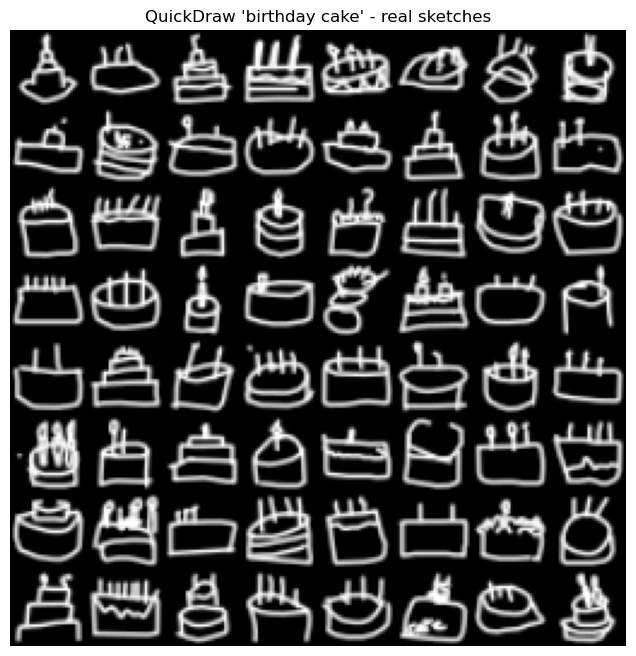

In [43]:
import urllib.request

QUICKDRAW_DIR = os.path.join(KERAS_RESULTS_DIR, "quickdraw")
os.makedirs(QUICKDRAW_DIR, exist_ok=True)

def fetch_category(name):
    """Fetch one QuickDraw numpy-bitmap category as (N, 28, 28) uint8. Needs internet."""
    target = os.path.join(QUICKDRAW_DIR, name.replace(" ", "_") + ".npy")
    if not os.path.exists(target):
        source = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/" + name.replace(" ", "%20") + ".npy"
        print("fetching", name)
        request = urllib.request.Request(source, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(request) as response, open(target, "wb") as handle:
            handle.write(response.read())
    return np.load(target).reshape(-1, 28, 28)


def ink_fraction(images_uint8, threshold=50):
    """Mean fraction of inked pixels, used as a rough complexity proxy."""
    return float((images_uint8 > threshold).mean())


cake_uint8 = fetch_category("birthday cake")
print("birthday cake sketches:", cake_uint8.shape)
montage(images_from_uint8(cake_uint8[:64]), "QuickDraw 'birthday cake' - real sketches",
        os.path.join(KERAS_RESULTS_DIR, "quickdraw_real_samples.png"))

## Build and train the DCGAN with `model.fit`

The Keras DCGAN uses a 100-d latent vector, a base of 48 feature maps, Adam at `lr=0.00015` (`beta_1=0.5`) for both networks, and trains for 35 epochs at batch size 256:

```
QuickDraw Keras config: {'latent': 100, 'base': 48, 'lr': 0.00015, 'epochs': 35, 'batch': 256, 'init_std': 0.02}
```

Training runs through the custom `DcganModel.train_step` via `model.fit`, printing `d_loss`/`g_loss` at each epoch. Just like the OCTMNIST run, the generator loss starts high while the discriminator is still weak (`d_loss=0.55, g_loss=2.84` at epoch 1), and the two losses drift closer together as training goes on, which is what a stable (non-collapsed) adversarial fit looks like here.

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ latent (InputLayer)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3072)           │       307,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 192)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 4, 4, 192)      │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 4, 4, 192)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 96)       │       294,912 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 96)       │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 8, 8, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 48)     │        73,728 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 1)      │           768 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 677,952 (2.59 MB)

 Trainable params: 677,280 (2.58 MB)

 Non-trainable params: 672 (2.62 KB)

Epoch 1/35
117/117 - 17s - 144ms/step - d_loss: 0.5456 - g_loss: 2.8398
Epoch 2/35
117/117 - 1s - 8ms/step - d_loss: 0.3981 - g_loss: 4.4147
Epoch 3/35
117/117 - 1s - 8ms/step - d_loss: 0.4402 - g_loss: 4.4478
Epoch 4/35
117/117 - 1s - 8ms/step - d_loss: 0.3953 - g_loss: 4.3268
Epoch 5/35
117/117 - 1s - 8ms/step - d_loss: 0.5397 - g_loss: 3.3609
Epoch 6/35
117/117 - 1s - 8ms/step - d_loss: 0.5960 - g_loss: 2.9338
Epoch 7/35
117/117 - 1s - 8ms/step - d_loss: 0.6123 - g_loss: 2.7197
Epoch 8/35
117/117 - 1s - 8ms/step - d_loss: 0.6095 - g_loss: 2.6719
Epoch 9/35
117/117 - 1s - 8ms/step - d_loss: 0.6457 - g_loss: 2.6706
Epoch 10/35
117/117 - 1s - 8ms/step - d_loss: 0.6176 - g_loss: 2.6726
Epoch 11/35
117/117 - 1s - 8ms/step - d_loss: 0.6319 - g_loss: 2.7063
Epoch 12/35
117/117 - 1s - 8ms/step - d_loss: 0.5935 - g_loss: 2.7112
Epoch 13/35
117/117 - 1s - 8ms/step - d_loss: 0.6174 - g_loss: 2.7438
Epoch 14/35
117/117 - 1s - 8ms/step - d_loss: 0.6586 - g_loss: 2.7388
Epoch 15/35
117/117 - 1s -

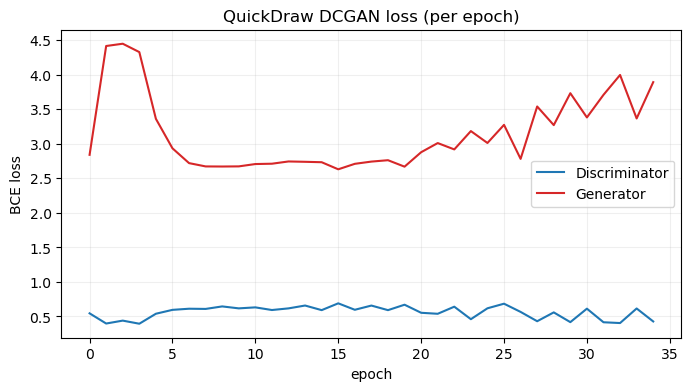

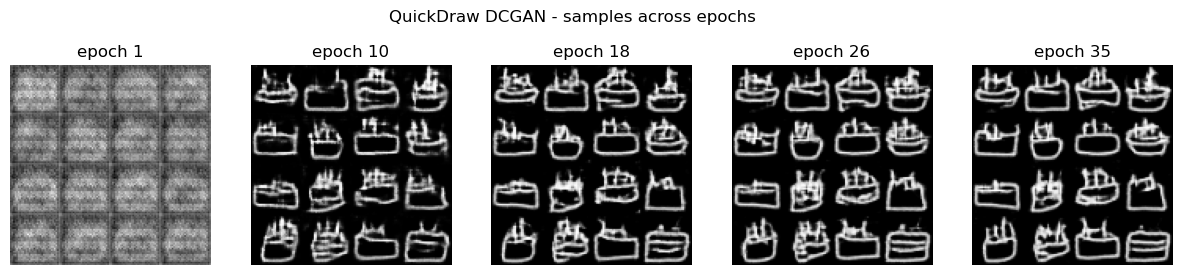

In [44]:
keras.utils.set_random_seed(KERAS_SEED)

cake_indices = np.random.permutation(len(cake_uint8))[:CAKE_MAX_IMAGES]
cake_dataset = (tf.data.Dataset.from_tensor_slices(images_from_uint8(cake_uint8[cake_indices]))
                .shuffle(min(len(cake_indices), 10000))
                .batch(CAKE_BATCH, drop_remainder=True)
                .prefetch(tf.data.AUTOTUNE))

cake_gan = DcganModel(make_generator(CAKE_LATENT, CAKE_BASE, CAKE_INIT_STD),
                      make_discriminator(CAKE_BASE, CAKE_INIT_STD),
                      latent_dim=CAKE_LATENT)
cake_gan.compile(
    d_optimizer=keras.optimizers.Adam(CAKE_LR, beta_1=CAKE_BETA1),
    g_optimizer=keras.optimizers.Adam(CAKE_LR, beta_1=CAKE_BETA1),
    loss_fn=keras.losses.BinaryCrossentropy(from_logits=True))
cake_gan.generator.summary()

cake_logger = EpochSampleLogger(CAKE_LATENT, CAKE_EPOCHS)
cake_history = cake_gan.fit(cake_dataset, epochs=CAKE_EPOCHS, callbacks=[cake_logger], verbose=2)

plt.figure(figsize=(8, 4))
plt.plot(cake_history.history["d_loss"], label="Discriminator", color="#1f77b4")
plt.plot(cake_history.history["g_loss"], label="Generator", color="#d62728")
plt.title("QuickDraw DCGAN loss (per epoch)"); plt.xlabel("epoch"); plt.ylabel("BCE loss")
plt.legend(); plt.grid(alpha=0.2)
plt.savefig(os.path.join(KERAS_RESULTS_DIR, "quickdraw_loss_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
show_progression(cake_logger.snapshots, "QuickDraw DCGAN - samples across epochs",
                 os.path.join(KERAS_RESULTS_DIR, "quickdraw_progression.png"))

## Generate, compare against real, and score FID

I sample fake sketches from the trained generator and show them two ways: as a standalone grid, and side by side with real cake sketches. FID is computed with the same InceptionV3-feature approach I used in Part 2.1 (through `InceptionFidScorer`), comparing real and generated sketches on the same footing (both mapped to `[0, 1]`):

```
QuickDraw 'birthday cake' DCGAN FID (lower is better): 41.32
```

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


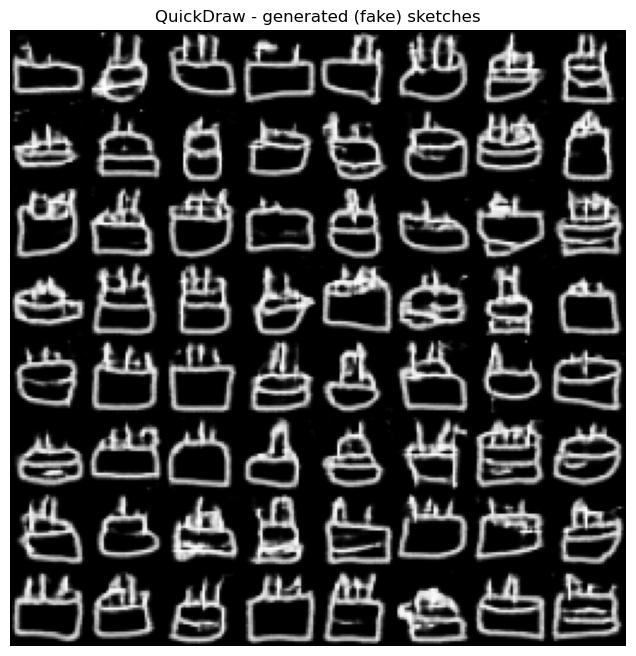

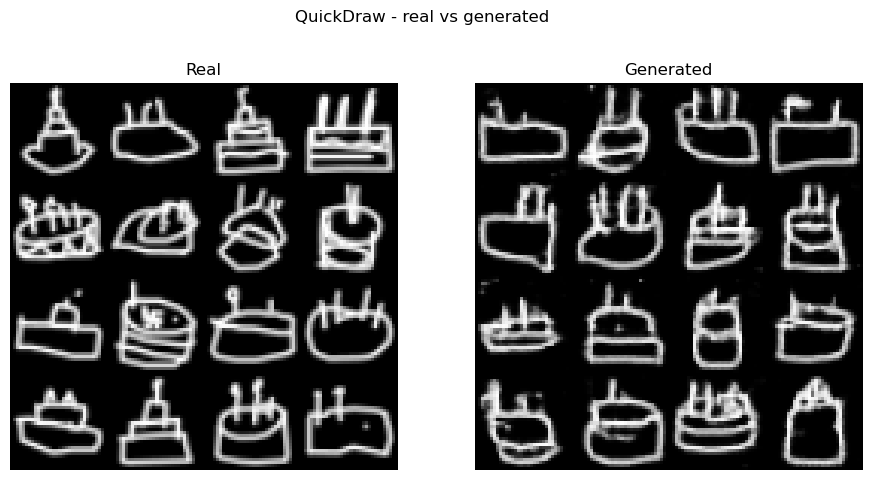

QuickDraw 'birthday cake' DCGAN FID (lower is better): 41.32


In [45]:
fid_scorer = InceptionFidScorer()

cake_fake = cake_gan.synthesize(CAKE_FID_SAMPLES)
montage(cake_fake[:64], "QuickDraw - generated (fake) sketches",
        os.path.join(KERAS_RESULTS_DIR, "quickdraw_fake_samples.png"))
side_by_side(images_from_uint8(cake_uint8[:16]), cake_fake[:16],
             "QuickDraw - real vs generated", os.path.join(KERAS_RESULTS_DIR, "quickdraw_real_vs_fake.png"))

cake_fid_idx = np.random.permutation(len(cake_uint8))[:CAKE_FID_SAMPLES]
cake_fid = fid_scorer.score(unit_from_signed(images_from_uint8(cake_uint8[cake_fid_idx])),
                            unit_from_signed(cake_fake))
print(f"QuickDraw 'birthday cake' DCGAN FID (lower is better): {cake_fid:.2f}")

## Other categories and sketch complexity (extension)

For the extension I retrain the same Keras DCGAN on a couple more categories, then compare an ink-fraction "complexity" proxy against the FID to see whether busier sketches are harder to model.

fetching cat
Epoch 1/35
117/117 - 8s - 69ms/step - d_loss: 0.5651 - g_loss: 2.8107
Epoch 2/35
117/117 - 1s - 8ms/step - d_loss: 0.4276 - g_loss: 4.3630
Epoch 3/35
117/117 - 1s - 8ms/step - d_loss: 0.4387 - g_loss: 3.9713
Epoch 4/35
117/117 - 1s - 8ms/step - d_loss: 0.4426 - g_loss: 4.1228
Epoch 5/35
117/117 - 1s - 8ms/step - d_loss: 0.4126 - g_loss: 3.7795
Epoch 6/35
117/117 - 1s - 8ms/step - d_loss: 0.4541 - g_loss: 3.8620
Epoch 7/35
117/117 - 1s - 8ms/step - d_loss: 0.5413 - g_loss: 3.1465
Epoch 8/35
117/117 - 1s - 8ms/step - d_loss: 0.5895 - g_loss: 2.9164
Epoch 9/35
117/117 - 1s - 8ms/step - d_loss: 0.6233 - g_loss: 2.8526
Epoch 10/35
117/117 - 1s - 8ms/step - d_loss: 0.5907 - g_loss: 2.7311
Epoch 11/35
117/117 - 1s - 8ms/step - d_loss: 0.6355 - g_loss: 2.6774
Epoch 12/35
117/117 - 1s - 8ms/step - d_loss: 0.6769 - g_loss: 2.6197
Epoch 13/35
117/117 - 1s - 8ms/step - d_loss: 0.6759 - g_loss: 2.5772
Epoch 14/35
117/117 - 1s - 8ms/step - d_loss: 0.6735 - g_loss: 2.4730
Epoch 15/35
117

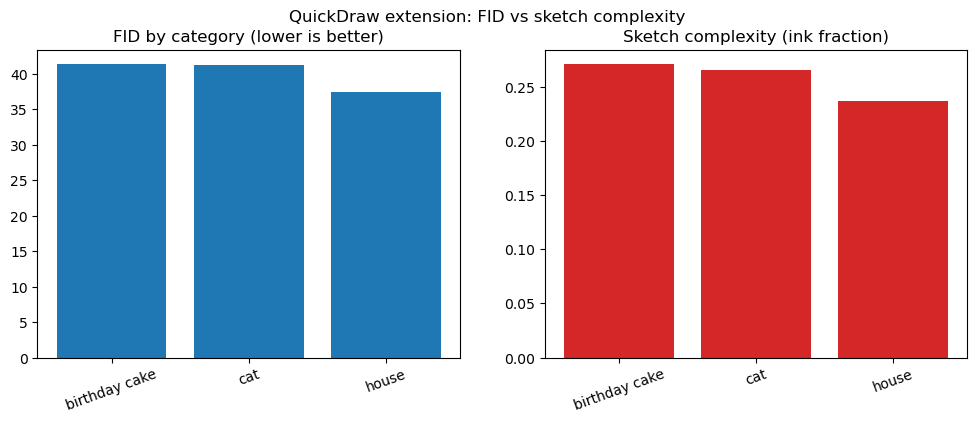

   birthday cake: FID=41.32 | ink=0.2708
             cat: FID=41.22 | ink=0.2655
           house: FID=37.39 | ink=0.2368


In [46]:
fid_by_category = {"birthday cake": cake_fid}
ink_by_category = {"birthday cake": ink_fraction(cake_uint8)}

for category in CAKE_EXTRA:
    keras.utils.set_random_seed(KERAS_SEED)
    category_uint8 = fetch_category(category)
    ink_by_category[category] = ink_fraction(category_uint8)
    category_idx = np.random.permutation(len(category_uint8))[:CAKE_MAX_IMAGES]
    category_dataset = (tf.data.Dataset.from_tensor_slices(images_from_uint8(category_uint8[category_idx]))
                        .shuffle(min(CAKE_MAX_IMAGES, 10000)).batch(CAKE_BATCH, drop_remainder=True)
                        .prefetch(tf.data.AUTOTUNE))
    category_gan = DcganModel(make_generator(CAKE_LATENT, CAKE_BASE, CAKE_INIT_STD),
                              make_discriminator(CAKE_BASE, CAKE_INIT_STD), latent_dim=CAKE_LATENT)
    category_gan.compile(d_optimizer=keras.optimizers.Adam(CAKE_LR, beta_1=CAKE_BETA1),
                         g_optimizer=keras.optimizers.Adam(CAKE_LR, beta_1=CAKE_BETA1),
                         loss_fn=keras.losses.BinaryCrossentropy(from_logits=True))
    category_gan.fit(category_dataset, epochs=CAKE_EPOCHS, verbose=2)
    category_fake = category_gan.synthesize(CAKE_FID_SAMPLES)
    category_ref = np.random.permutation(len(category_uint8))[:CAKE_FID_SAMPLES]
    fid_by_category[category] = fid_scorer.score(
        unit_from_signed(images_from_uint8(category_uint8[category_ref])), unit_from_signed(category_fake))
    print(f"QuickDraw '{category}': FID={fid_by_category[category]:.2f} | ink={ink_by_category[category]:.4f}")

labels = list(fid_by_category.keys())
figure, (ax_fid, ax_ink) = plt.subplots(1, 2, figsize=(12, 4))
ax_fid.bar(labels, [fid_by_category[k] for k in labels], color="#1f77b4")
ax_fid.set_title("FID by category (lower is better)"); ax_fid.tick_params(axis="x", rotation=20)
ax_ink.bar(labels, [ink_by_category[k] for k in labels], color="#d62728")
ax_ink.set_title("Sketch complexity (ink fraction)"); ax_ink.tick_params(axis="x", rotation=20)
figure.suptitle("QuickDraw extension: FID vs sketch complexity")
figure.savefig(os.path.join(KERAS_RESULTS_DIR, "quickdraw_extension_complexity.png"), dpi=150, bbox_inches="tight")
plt.show()
for k in labels:
    print(f"  {k:>14}: FID={fid_by_category[k]:.2f} | ink={ink_by_category[k]:.4f}")

## Reflection

The generated cakes are recognisable - a rounded or rectangular body, candles on top, and often a plate underneath. There are line-art faults up close (broken strokes, a bit of speckle), but they don't hide what the drawing is, which fits the FID of 41.32. The `d_loss`/`g_loss` stay in a healthy back-and-forth with only the occasional spike.

Looking across categories: house (37.39) is clearly the easiest, while cat (41.22) and cake (41.32) come out almost level. The ink-fraction values (0.237, 0.266, 0.271) are nearly flat, so ink density on its own doesn't explain the differences. The harder categories seem to be the ones with more shape variety - cake bodies, tiers and different candle counts, and cats in varied poses - though the small cat-vs-cake gap here is really within run-to-run noise rather than a firm difficulty ranking I'd want to lean on.

As with the other parts, the model can draw fluent strokes that don't quite add up to a coherent object, so I wouldn't use these sketches as training data somewhere else without a manual review first.

# Key findings (summary)

Pulling the whole notebook together:

**Part 1** showed a from-scratch GAN learning a sine wave cleanly, reaching all eight modes of a Gaussian mixture (if a bit loosely), and then sharpening those samples noticeably once I made the generator deeper and wider and switched it to SELU.

**Part 2.1** trained a DCGAN that produces plausible OCT scans (FID 43.70) plus a conditional version I can ask for a specific diagnostic class, with class-balanced sampling handling the dataset's imbalance.

**Part 2.2** used a dense feature-vector GAN (not a conv net, since the data are tabular flows) on the Wednesday BENIGN-vs-DoS split. The PCA/t-SNE plots and the mean/std gaps show the synthetic traffic matching the bulk of the real distribution but missing the tails, and the all-days extension confirms that one GAN struggles to span every attack family.

**Part 2.3** trained a Keras DCGAN on QuickDraw cakes (FID 41.32) plus two more categories, where the cross-category comparison suggests difficulty comes from shape variety rather than raw ink density.

Every figure and FID number I quote in the report comes straight out of this notebook.